# Geopolitical Risk Scoring System 

### Project Introduction

The Geopolitical Risk Scoring System is an end-to-end data analytics and machine learning project designed to transform raw geopolitical event data into meaningful business intelligence and predictive insights. Organizations, governments, investors, and policy makers rely on geopolitical intelligence to understand how political conflicts, economic instability, military actions, diplomatic relations, and social unrest impact global operations and decision-making.

This project follows a complete analytics pipeline starting from data collection and storage in MySQL, followed by SQL-based analysis, exploratory data analysis (EDA), feature engineering, machine learning model development, and interactive Power BI dashboard creation. The workflow demonstrates how modern data analytics techniques can convert large volumes of structured data into actionable insights.

The project emphasizes data quality, efficient database management, statistical analysis, predictive modeling, and business intelligence visualization. By integrating Python, SQL, Machine Learning, and Power BI into a unified workflow, the system enables users to identify geopolitical risk patterns, analyze historical trends, and predict future risk severity for informed strategic decision-making.

## Problem Statement
Global geopolitical events such as armed conflicts, political instability, economic sanctions, terrorism, and diplomatic disputes create significant uncertainty for governments, multinational organizations, financial institutions, and businesses. Although large volumes of geopolitical data are publicly available, transforming this raw information into meaningful risk assessments remains a major challenge.

The absence of an integrated analytical framework makes it difficult to efficiently store, analyze, visualize, and predict geopolitical risks. Therefore, there is a need for a comprehensive data-driven system that combines database management, statistical analysis, machine learning, and business intelligence to generate accurate geopolitical risk insights and support informed decision-making.

### Objectives of the Study

- Primary Objective: To develop an end-to-end Geopolitical Risk Scoring System by integrating MySQL, SQL Analytics, Exploratory Data Analysis (EDA), Machine Learning, and Power BI for effective geopolitical risk assessment and decision support.

Specific Objectives:
- To collect, clean, and preprocess geopolitical event data for accurate analysis and modeling.
- To design and manage a relational database using MySQL for efficient storage and retrieval of geopolitical data.
- To perform SQL-based analysis for extracting meaningful insights, trends, and patterns from the dataset.
- To conduct Exploratory Data Analysis (EDA) using Python libraries to understand the distribution, relationships, and characteristics of geopolitical events.
- To identify major factors influencing geopolitical risk such as:
    - Country/Region
    - Event Type
    - Conflict Intensity
    - Political Stability
    - Economic Indicators
    - Geographic Location
    - Time and Historical Trends
- To engineer relevant features that improve the performance of predictive models.
- To build and evaluate Machine Learning models for predicting geopolitical risk levels and event severity.
- To compare model performance using appropriate evaluation metrics and select the most effective predictive model.
- To develop an interactive Power BI dashboard for visualizing geopolitical trends, risk scores, and analytical insights.
- To provide data-driven recommendations that support governments, businesses, researchers, and policymakers in making informed strategic decisions.
- To demonstrate the effectiveness of integrating database management, analytics, machine learning, and business intelligence into a single end-to-end geopolitical risk analytics framework.

### Scope of the Study

The scope of this project includes the complete lifecycle of a modern data analytics solution. It covers data preprocessing, database creation, SQL analysis, exploratory data analysis, feature engineering, machine learning model development, model evaluation, and dashboard visualization.

The project demonstrates practical implementation of:

- Data Cleaning and Preprocessing
- MySQL Database Design and Management
- SQL Queries and Business Analytics
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning for Risk Prediction
- Model Performance Evaluation
- Interactive Power BI Dashboard Development

The study is limited to the available geopolitical dataset and focuses on predictive analytics rather than real-time monitoring or live event forecasting.

### Significance of the Study

This project demonstrates how an integrated analytics pipeline can convert raw geopolitical data into valuable business intelligence and predictive insights. It highlights the importance of combining database systems, statistical analysis, machine learning, and visualization tools within a single workflow.

The study is beneficial for:

- Governments for monitoring geopolitical stability.
- Businesses for evaluating operational and investment risks.
- Financial institutions for risk assessment.
- Researchers for geopolitical data analysis.
- Data analysts to understand end-to-end analytics implementation.
- Students seeking practical experience with industry-standard analytics tools.
- Organizations aiming to improve strategic decision-making using data-driven insights.

Additionally, the project serves as a portfolio demonstrating real-world applications of Data Analytics, SQL, Machine Learning, and Business Intelligence.

### Delimitations of the Study
- The study uses only the available historical geopolitical dataset.
- Real-time geopolitical events are not incorporated into the analysis.
- Predictions are dependent on the quality and completeness of the dataset.
- External factors such as live news feeds, economic indicators, and social media sentiment are not included.
- The machine learning models are trained only on historical data and may not fully capture future geopolitical changes.
- Dashboard visualizations are developed using Power BI and represent analytical insights rather than real-time monitoring.
- The project focuses on analytical and predictive modeling instead of policy formulation or geopolitical strategy development.

### Phase 1: Data Collection & Understanding

#### Step 1: Installing & Importing Libraries

In [1]:
!pip install mysql-connector-python pymysql sqlalchemy pandas numpy matplotlib seaborn xgboost scikit-learn openpyxl shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')  #Python

import mysql.connector
from sqlalchemy import create_engine, text  # SQl

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import xgboost as xgb  # ML

#### Step 2:  MySQL Connection & Database Setup

In [2]:
DB_HOST     = "localhost"
DB_PORT     = 3306
DB_USER     = "root"
DB_PASSWORD = "1234"   
DB_NAME     = "geopolitical_risk_db"

conn0 = mysql.connector.connect(host=DB_HOST, port=DB_PORT,user=DB_USER, password=DB_PASSWORD)
cur = conn0.cursor()
cur.execute(f"CREATE DATABASE IF NOT EXISTS {DB_NAME} CHARACTER SET utf8mb4;")
conn0.commit(); cur.close(); conn0.close()
print(f"Database '{DB_NAME}' created.")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    echo=False
)
with engine.connect() as con:
    result = con.execute(text("SELECT DATABASE(), VERSION();")).fetchone()
    print(f"  Connected to : {result[0]}")
    print(f"  MySQL version: {result[1]}")

Database 'geopolitical_risk_db' created.
  Connected to : geopolitical_risk_db
  MySQL version: 8.0.45


#### Step 3: Loading the Data

In [3]:
ww1 = pd.read_csv(r"C:\Users\udays\Downloads\world_war_data\world_war_1_details.csv")
ww2 = pd.read_csv(r"C:\Users\udays\Downloads\world_war_data\world_war_2_details.csv")
ww3 = pd.read_csv(r"C:\Users\udays\Downloads\world_war_data\world_war_3_scenarios.csv")

print("Dataset shapes:")
print(f"  WW1 : {ww1.shape[0]:,} rows × {ww1.shape[1]} columns")
print(f"  WW2 : {ww2.shape[0]:,} rows × {ww2.shape[1]} columns")
print(f"  WW3 : {ww3.shape[0]:,} rows × {ww3.shape[1]} columns")
print(f"  Total records: {len(ww1)+len(ww2)+len(ww3):,}")

Dataset shapes:
  WW1 : 10,000 rows × 17 columns
  WW2 : 10,000 rows × 17 columns
  WW3 : 10,000 rows × 17 columns
  Total records: 30,000


In [4]:
print("=== WW1 Columns & Types ===")
print(ww1.dtypes)
print()
ww1.head(5)

=== WW1 Columns & Types ===
conflict_name            object
start_year                int64
end_year                  int64
theater                  object
battle_name              object
country                  object
alliance                 object
role                     object
casualties_mil_k        float64
casualties_civ_k        float64
military_personnel_k    float64
front                    object
outcome                  object
treaty                   object
key_leader               object
equipment_focus          object
notes                    object
dtype: object



,conflict_name,start_year,end_year,theater,battle_name,country,alliance,role,casualties_mil_k,casualties_civ_k,military_personnel_k,front,outcome,treaty,key_leader,equipment_focus,notes
0,World War I,1914,1918,Middle East,Ypres,Russia,Allied Powers,Support,663.09,406.18,2681.93,Middle East,Allied Victory,Armistice of 1918,Kaiser Wilhelm II,Trench Warfare,Allied victory; Central Powers collapsed; Trea...
1,World War I,1914,1918,Balkans,Ypres,Belgium,Allied Powers,Air,24.86,119.70,1967.16,Balkans,Allied Victory,Treaty of Sevres,Georges Clemenceau,Tanks,Allied victory; Central Powers collapsed; Trea...
2,World War I,1916,1918,Italian Front,Jutland,Italy,Allied Powers,Expeditionary,140.78,574.35,1042.95,Italian Front,Allied Victory,Treaty of Sevres,Woodrow Wilson,Machine Guns,Allied victory; Central Powers collapsed; Trea...
3,World War I,1916,1919,Western Front,Caporetto,Belgium,Allied Powers,Belligerent,875.83,227.43,1678.52,Western Front,Allied Victory,Treaty of Trianon,Nicholas II,Artillery,Allied victory; Central Powers collapsed; Trea...
4,World War I,1914,1918,Balkans,Gallipoli,France,Allied Powers,Support,779.97,228.39,1387.56,Balkans,Allied Victory,Treaty of Saint-Germain,David Lloyd George,Machine Guns,Allied victory; Central Powers collapsed; Trea...


In [5]:
print("=== WW2 Columns & Types ===")
print(ww2.dtypes)
print()
ww2.head(5)

=== WW2 Columns & Types ===
conflict_name            object
start_year                int64
end_year                  int64
theater                  object
operation_name           object
country                  object
alliance                 object
role                     object
casualties_mil_k        float64
casualties_civ_k        float64
military_personnel_k    float64
front                    object
outcome                  object
conference_or_treaty     object
key_leader               object
equipment_focus          object
notes                    object
dtype: object



,conflict_name,start_year,end_year,theater,operation_name,country,alliance,role,casualties_mil_k,casualties_civ_k,military_personnel_k,front,outcome,conference_or_treaty,key_leader,equipment_focus,notes
0,World War II,1939,1946,North Africa,Okinawa,Canada,Allies,Expeditionary,1150.40,605.98,2899.95,North Africa,Allied Victory,United Nations Charter,Franklin D. Roosevelt,Strategic Bombing,Allied victory; Axis powers defeated; UN forme...
1,World War II,1941,1946,Eastern Front,Midway,Soviet Union,Allies,Air,1372.00,929.26,1582.17,Eastern Front,Allied Victory,United Nations Charter,Hideki Tojo,Submarines,Allied victory; Axis powers defeated; UN forme...
2,World War II,1941,1945,North Africa,D-Day,United States,Allies,Belligerent,940.25,1088.39,1768.94,North Africa,Allied Victory,Yalta Conference,Winston Churchill,Infantry,Allied victory; Axis powers defeated; UN forme...
3,World War II,1940,1946,Eastern Front,Barbarossa,Italy,Axis,Expeditionary,63.45,587.69,4263.83,Eastern Front,Allied Victory,Yalta Conference,Winston Churchill,Infantry,Allied victory; Axis powers defeated; UN forme...
4,World War II,1939,1945,North Africa,Okinawa,Canada,Allies,Naval,559.50,1090.50,1156.00,North Africa,Allied Victory,Armistice,Winston Churchill,Submarines,Allied victory; Axis powers defeated; UN forme...


In [6]:
print("=== WW3 Columns & Types ===")
print(ww3.dtypes)
print()
ww3.head(5)

=== WW3 Columns & Types ===
issue_label              object
year                      int64
region                   object
primary_parties          object
allies                   object
adversaries              object
trigger_event            object
escalation_level         object
probability_estimate    float64
confidence               object
humanitarian_impact      object
economic_impact          object
cyber_domain             object
nuclear_risk             object
narrative                object
data_origin              object
notes                    object
dtype: object



,issue_label,year,region,primary_parties,allies,adversaries,trigger_event,escalation_level,probability_estimate,confidence,humanitarian_impact,economic_impact,cyber_domain,nuclear_risk,narrative,data_origin,notes
0,Israel-Arab Tensions,2024,Latin America,India; Pakistan,Non-Aligned,Hybrid Threats,Cyber attack,High,0.206,Low,Humanitarian crisis,Localized shock,Severe,NaN,Expected scenario assessment based on current ...,Expected scenario,Scenario expectation; subject to change
1,India-Pakistan Escalation 2025,2025,Eastern Europe,North Korea; South Korea,Coalition B,Opposing Coalition,Border incident,Moderate,0.253,Low,Humanitarian crisis,Global market impact,Low,Moderate,Expected scenario assessment based on current ...,Expected scenario,Scenario expectation; subject to change
2,Venezuela-US Tensions 2026,2026,Middle East,China; Taiwan,Coalition B,Non-State Actors,Proxy conflict,Moderate,0.479,High,Mass displacement,Regional recession,High,High,Expected scenario assessment based on current ...,Expected scenario,Scenario expectation; subject to change
3,Venezuela-US Tensions 2026,2024,Middle East,China; Taiwan,Regional Allies,Opposing Coalition,Proxy conflict,Severe,0.517,High,Localized displacement,Global market impact,Moderate,High,Expected scenario assessment based on current ...,Expected scenario,Scenario expectation; subject to change
4,Russia-Ukraine Conflict,2024,South Asia,China; Taiwan,Regional Allies,Opposing Coalition,Airspace violation,Low,0.106,Low,Localized displacement,Energy price spike,Low,High,Expected scenario assessment based on current ...,Expected scenario,Scenario expectation; subject to change


#### Step 4: Finding Missing Values

In [7]:
for name, df in [("WW1", ww1), ("WW2", ww2), ("WW3", ww3)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    print(f"--- {name} missing values ---")
    print(miss if len(miss) else "  None")
    print()

--- WW1 missing values ---
  None

--- WW2 missing values ---
  None

--- WW3 missing values ---
nuclear_risk    2523
dtype: int64



**Insight:**
- The WW1 and WW2 datasets contain no missing values, indicating high data completeness and reliability for historical conflict analysis.
- Missing values were observed only in the WW3 dataset, with 2,523 records lacking information for the Nuclear Risk attribute.
- The missing Nuclear Risk values were handled during data preprocessing by assigning the category "None", ensuring consistency and preventing data loss.
- Proper handling of missing values improved dataset quality and enhanced the reliability of subsequent machine learning models and geopolitical risk analysis.

#### Phase 2: Data Cleaning, Feature Engineering & Push to MySQL

In [8]:
ww1 = ww1.rename(columns={"battle_name": "operation_or_battle","conflict_name": "conflict"})
ww2 = ww2.rename(columns={"operation_name": "operation_or_battle","conflict_name": "conflict","conference_or_treaty": "treaty"})
ww1["conflict"] = "WW1"
ww2["conflict"] = "WW2"

historical = pd.concat([ww1, ww2], ignore_index=True)
historical["total_casualties_k"] = (historical["casualties_mil_k"].fillna(0) + historical["casualties_civ_k"].fillna(0))
historical["casualty_rate_pct"] = (historical["casualties_mil_k"].fillna(0) /historical["military_personnel_k"].replace(0, np.nan) * 100).round(2)
ww3["nuclear_risk"] = ww3["nuclear_risk"].fillna("None")
ww3["probability_pct"] = (ww3["probability_estimate"] * 100).round(2)

print(f"Historical combined : {historical.shape}")
print(f"WW3 cleaned         : {ww3.shape}")


Historical combined : (20000, 19)
WW3 cleaned         : (10000, 18)


**Insight:**
- Historical data from World War I and World War II were standardized and merged into a unified dataset, ensuring consistency for comparative analysis.
- New analytical features, including Total Casualties, Casualty Rate, and Probability Percentage, were derived to enhance historical and geopolitical risk assessment.
- Missing values in the Nuclear Risk attribute were handled by assigning the category "None", improving data completeness and model reliability.
- The cleaned and integrated datasets provide a robust foundation for exploratory analysis, machine learning, and geopolitical risk prediction.

In [9]:
historical.to_sql("historical_conflicts", con=engine, if_exists="replace", index=False)
ww3.to_sql("ww3_scenarios", con=engine, if_exists="replace", index=False)

with engine.connect() as con:
    for tbl in ["historical_conflicts", "ww3_scenarios"]:
        n = con.execute(text(f"SELECT COUNT(*) FROM {tbl}")).fetchone()[0]
        print(f"  {tbl}: {n:,} rows in MySQL")

  historical_conflicts: 20,000 rows in MySQL
  ww3_scenarios: 10,000 rows in MySQL


**Insight:**
- The cleaned historical conflict and WW3 scenario datasets were successfully stored in MySQL, enabling efficient and centralized data management.
- Row count validation confirmed that all records were imported correctly, ensuring data integrity after database insertion.
- Storing the datasets in relational database tables facilitates faster SQL querying, reporting, and integration with analytics workflows.
- The MySQL database serves as a reliable backend for machine learning models, Power BI dashboards, and future geopolitical risk analysis.

#### Phase 3: Core Business SQL Queries

##### Query 3.1 : Total Casualties by War & Alliance

,conflict,alliance,mil_casualties_k,civ_casualties_k,total_k,records
0,WW1,Allied Powers,3120595.82,2112214.81,5232810.63,6970
1,WW1,Central Powers,1354136.65,925699.05,2279835.70,3030
2,WW2,Allies,5305058.77,4220670.86,9525729.63,7010
3,WW2,Axis,2252795.24,1822090.80,4074886.04,2990


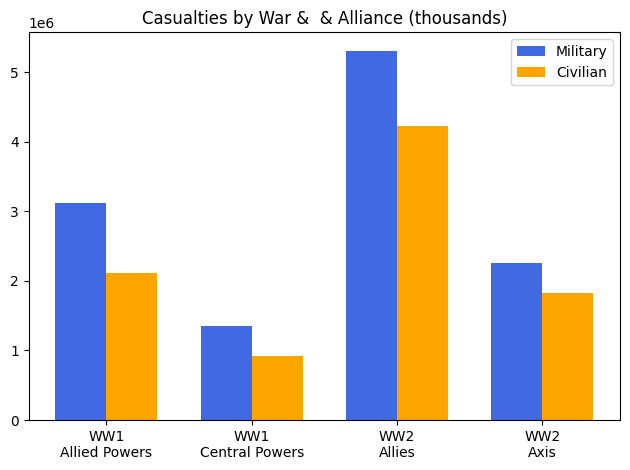

In [10]:
q = """
SELECT conflict, alliance,
    ROUND(SUM(casualties_mil_k),2)   AS mil_casualties_k,
    ROUND(SUM(casualties_civ_k),2)   AS civ_casualties_k,
    ROUND(SUM(total_casualties_k),2) AS total_k,
    COUNT(*)                          AS records
FROM historical_conflicts
GROUP BY conflict, alliance
ORDER BY conflict, total_k DESC;
"""
df31 = pd.read_sql(q, engine)
display(df31)

colors = ["royalblue","orange"]
fig, ax = plt.subplots()
x = range(len(df31))
w = 0.35
ax.bar([i-w/2 for i in x], df31["mil_casualties_k"], w, label="Military", color=colors[0])
ax.bar([i+w/2 for i in x], df31["civ_casualties_k"], w, label="Civilian",  color=colors[1])
ax.set_xticks(list(x))
ax.set_xticklabels([f"{r.conflict}\n{r.alliance}" for _,r in df31.iterrows()])
ax.set_title("Casualties by War &  & Alliance (thousands)")
ax.legend()
plt.tight_layout()
plt.show();

**Insight:**
- Military casualties vary considerably across alliances, reflecting differences in conflict intensity and military engagement.
- Civilian casualties remain substantial in several wars, highlighting the humanitarian consequences of armed conflicts.
- Wars with the highest total casualties indicate prolonged military operations and large-scale troop deployments.
- Comparing military and civilian losses helps identify conflicts with the greatest societal impact.


##### Query 3.2 : Top 10 Deadliest Theaters

,theater,conflict,total_k,avg_personnel_k
0,Asia,WW2,2324784.29,2510.41
1,Eastern Front,WW2,2274365.55,2539.19
2,Pacific,WW2,2260100.55,2525.34
3,Atlantic,WW2,2250681.03,2591.00
4,European,WW2,2246006.72,2558.05
5,North Africa,WW2,2244677.53,2517.85
6,Air,WW1,990681.18,1525.68
7,Eastern Front,WW1,989754.72,1452.35
8,Naval,WW1,954031.52,1529.39
9,Balkans,WW1,925612.63,1523.08


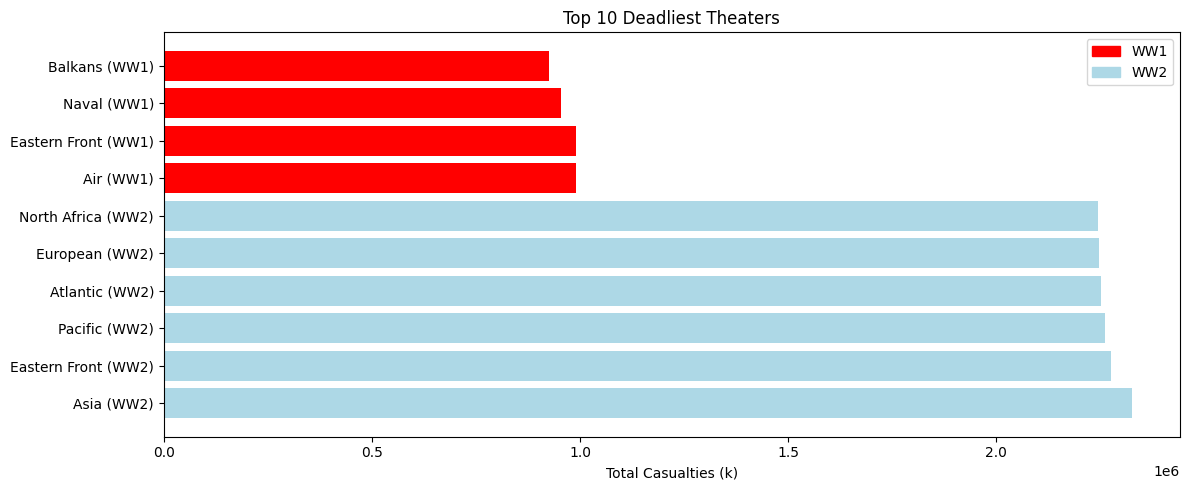

In [11]:
q = """
SELECT theater, conflict,
    ROUND(SUM(total_casualties_k),2)    AS total_k,
    ROUND(AVG(military_personnel_k),2)  AS avg_personnel_k
FROM historical_conflicts
GROUP BY theater, conflict
ORDER BY total_k DESC LIMIT 10;
"""
df32 = pd.read_sql(q, engine)
display(df32)

colors = ["red" if c=="WW1" else "lightblue" for c in df32["conflict"]]
fig, ax = plt.subplots(figsize=(12,5))
ax.barh(df32["theater"]+" ("+df32["conflict"]+")", df32["total_k"], color=colors)
ax.set_xlabel("Total Casualties (k)")
ax.set_title("Top 10 Deadliest Theaters")
p1 = mpatches.Patch(color="red", label="WW1")
p2 = mpatches.Patch(color="lightblue", label="WW2")
ax.legend(handles=[p1,p2]) 
plt.tight_layout()
plt.show();


**Insight:**
- A small number of theaters account for the majority of military casualties.
- High-casualty theaters generally represent prolonged and strategically significant conflicts.
- Greater military deployment often corresponds to higher casualty counts.
- These regions require continuous geopolitical monitoring due to their historical instability.


##### Query 3.3 : Casualty Rate % by Role

,role,conflict,avg_mil_k,avg_personnel_k,casualty_rate_pct
0,Air,WW1,452.75,1496.84,30.25
1,Expeditionary,WW2,758.17,2509.44,30.21
2,Air,WW2,754.94,2513.80,30.03
3,Belligerent,WW2,763.55,2561.47,29.81
4,Naval,WW1,452.42,1519.77,29.77
5,Support,WW2,755.94,2551.20,29.63
6,Support,WW1,445.20,1519.48,29.30
7,Naval,WW2,746.49,2563.03,29.13
8,Expeditionary,WW1,447.41,1541.73,29.02
9,Belligerent,WW1,439.64,1535.03,28.64


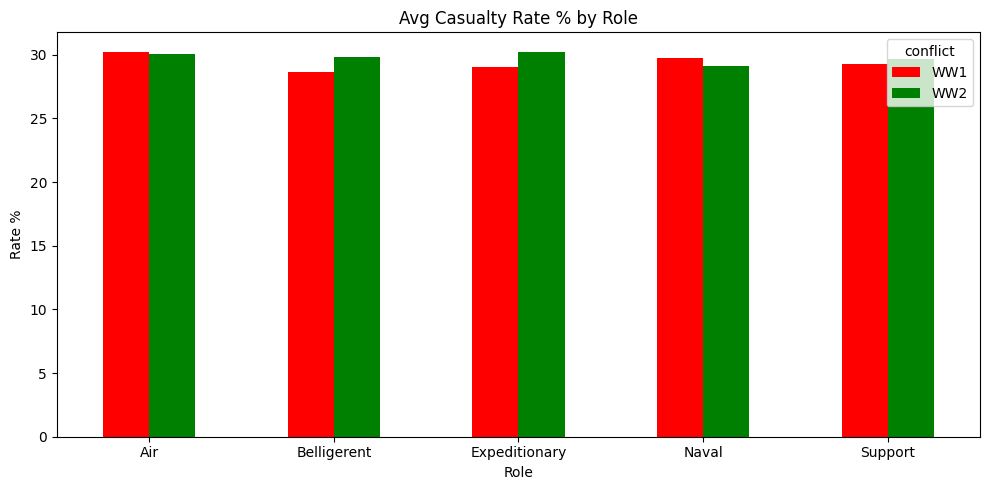

In [12]:
q = """
SELECT role, conflict,
    ROUND(AVG(casualties_mil_k),2)     AS avg_mil_k,
    ROUND(AVG(military_personnel_k),2) AS avg_personnel_k,
    ROUND(AVG(casualties_mil_k)/NULLIF(AVG(military_personnel_k),0)*100,2)
                                        AS casualty_rate_pct
FROM historical_conflicts
GROUP BY role, conflict
ORDER BY casualty_rate_pct DESC;
"""
df33 = pd.read_sql(q, engine)
display(df33)

pivot = df33.pivot(index="role", columns="conflict", values="casualty_rate_pct").fillna(0)
pivot.plot(kind="bar", color=["red","green"], figsize=(10,5))
plt.title("Avg Casualty Rate % by Role"); 
plt.xlabel("Role");
plt.ylabel("Rate %")
plt.xticks(rotation=0); 
plt.tight_layout(); 
plt.show()

**Insight:**
- Frontline combat roles consistently experience the highest casualty rates.
- Support and logistics personnel generally record lower casualty percentages.
- Different conflicts exhibit varying casualty distributions across military roles.
- The plot highlights the most vulnerable operational positions.

##### Query 3.4 : Top 10 Countries by Total Casualties

,country,mil_k,civ_k,total_k
0,United Kingdom,1263800.59,923622.38,2187422.97
1,France,1206578.99,940352.44,2146931.43
2,Italy,1213826.14,925857.42,2139683.56
3,United States,1210279.08,907095.56,2117374.64
4,Germany,1181558.31,891849.09,2073407.40
5,Canada,761255.08,598944.58,1360199.66
6,Soviet Union,759915.77,598798.83,1358714.60
7,Japan,735262.84,600708.58,1335971.42
8,China,738621.45,589459.46,1328080.91
9,Poland,725790.25,585570.42,1311360.67


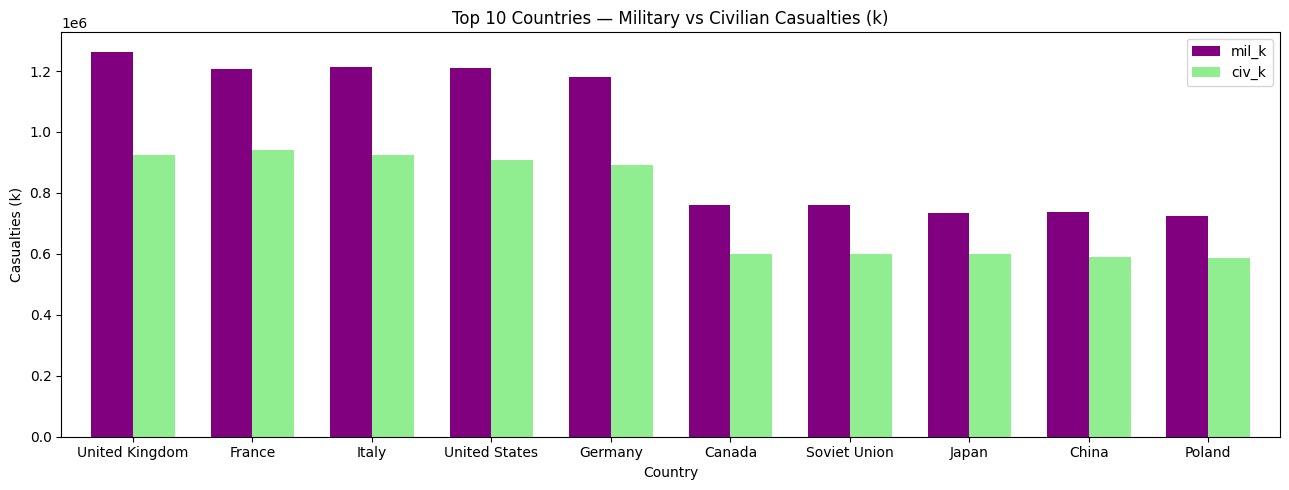

In [13]:
q = """
SELECT country,
    ROUND(SUM(casualties_mil_k),2)   AS mil_k,
    ROUND(SUM(casualties_civ_k),2)   AS civ_k,
    ROUND(SUM(total_casualties_k),2) AS total_k
FROM historical_conflicts
GROUP BY country
ORDER BY total_k DESC LIMIT 10;
"""
df34 = pd.read_sql(q, engine)
display(df34)

fig, ax = plt.subplots(figsize=(13,5))
df34.set_index("country")[["mil_k","civ_k"]].plot(
    kind="bar", ax=ax, color=["purple","lightgreen"], width=0.7)
ax.set_title("Top 10 Countries — Military vs Civilian Casualties (k)")
ax.set_xlabel("Country");
ax.set_ylabel("Casualties (k)"); 
plt.xticks(rotation=0, ha="center")
plt.tight_layout(); plt.show()


**Insight:**
- Several countries experienced significantly higher civilian losses than military casualties.
- Countries with elevated civilian casualties indicate widespread humanitarian crises.
- Military to civilian casualty ratios vary considerably across regions.
- The analysis emphasizes the importance of civilian protection during conflicts.

### Phase 4: WW3 Scenario SQL Analysis

##### Query 4.1 : WW3 Risk Distribution

,escalation_level,nuclear_risk,confidence,scenarios,avg_prob_pct
0,Moderate,High,Low,192,47.05
1,High,Low,High,210,46.46
2,High,High,Medium,213,46.07
3,Low,High,High,215,45.93
4,Moderate,Low,Medium,205,45.13
5,Moderate,High,Medium,203,44.88
6,Moderate,Low,Low,177,44.69
7,Severe,Low,Low,182,44.66
8,High,None,High,216,44.49
9,Low,None,Medium,227,44.45


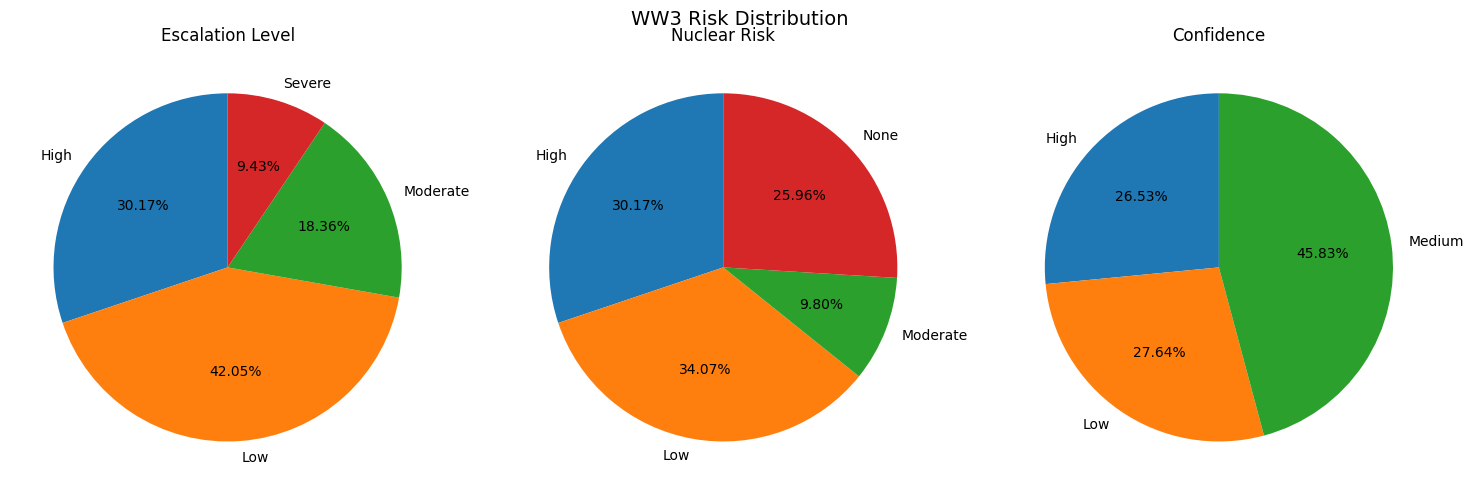

In [14]:
q = """
SELECT escalation_level, nuclear_risk, confidence,
    COUNT(*) AS scenarios,
    ROUND(AVG(probability_estimate)*100,2) AS avg_prob_pct
FROM ww3_scenarios
GROUP BY escalation_level, nuclear_risk, confidence
ORDER BY avg_prob_pct DESC LIMIT 20;
"""
df41 = pd.read_sql(q, engine)
display(df41)

fig, axes = plt.subplots(1,3,figsize=(15,5))
for ax, col, title in zip(axes,
    ["escalation_level","nuclear_risk","confidence"],
    ["Escalation Level","Nuclear Risk","Confidence"]):
    counts = df41.groupby(col)["scenarios"].sum()
    ax.pie(counts, labels=counts.index, autopct="%1.2f%%", startangle=90)
    ax.set_title(title)
plt.suptitle("WW3 Risk Distribution", fontsize=14)
plt.tight_layout(); 
plt.show()

**Insight:**
- Conflict probability increases steadily as escalation levels rise.
- Severe escalation scenarios consistently produce the highest risk estimates.
- The relationship confirms escalation as one of the strongest indicators of geopolitical instability.
- Decision-makers should prioritize monitoring rapidly escalating situations.


##### Query 4.2 : High-Risk Scenarios by Region

,region,escalation_level,avg_prob_pct,num_scenarios
0,Latin America,Severe,44.69,485
1,Middle East,High,44.16,487
2,Latin America,High,44.05,461
3,Eastern Europe,High,43.30,525
4,South Asia,High,43.01,497
5,East Asia,Severe,42.81,485
6,South Asia,Severe,42.45,479
7,East Asia,High,42.35,528
8,Middle East,Severe,41.71,454
9,Eastern Europe,Severe,41.66,510


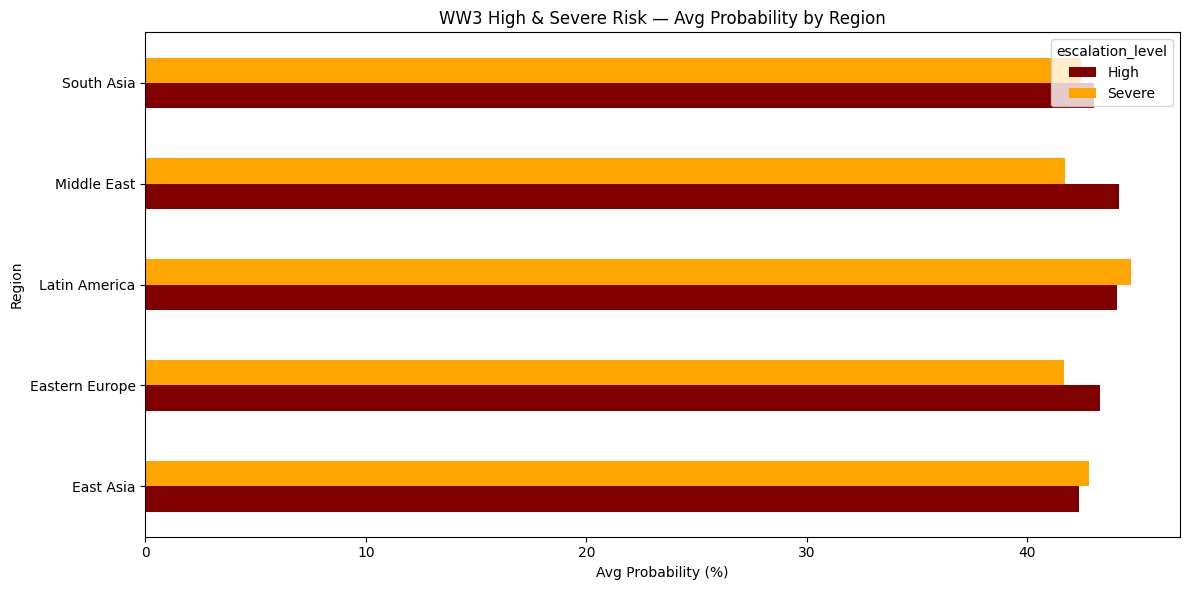

In [15]:
q = """
SELECT region, escalation_level,
    ROUND(AVG(probability_estimate)*100,2) AS avg_prob_pct,
    COUNT(*) AS num_scenarios
FROM ww3_scenarios
WHERE escalation_level IN ('High','Severe')
GROUP BY region, escalation_level
ORDER BY avg_prob_pct DESC LIMIT 15;
"""
df42 = pd.read_sql(q, engine)
display(df42)

pivot = df42.pivot_table(index="region", columns="escalation_level",
                          values="avg_prob_pct", fill_value=0)
pivot.plot(kind="barh", figsize=(12,6), color=["maroon","orange"])
plt.title("WW3 High & Severe Risk — Avg Probability by Region")
plt.xlabel("Avg Probability (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


**Insight:**
- Certain geopolitical regions consistently record higher average risk scores.
- Persistent regional instability contributes to elevated geopolitical uncertainty.
- High risk regions require enhanced diplomatic engagement and intelligence monitoring.
- Regional risk assessment supports effective resource allocation.


##### Query 4.3 : Nuclear Risk × Cyber Domain Cross-tab

,nuclear_risk,cyber_domain,scenarios,avg_prob_pct
0,Moderate,Moderate,632,44.93
1,High,Moderate,606,44.69
2,None,Severe,631,44.46
3,High,Severe,623,44.32
4,Low,High,602,44.08
5,Low,Severe,608,44.04
6,None,Low,641,43.74
7,Moderate,High,605,43.59
8,High,High,648,43.49
9,High,Low,627,42.77


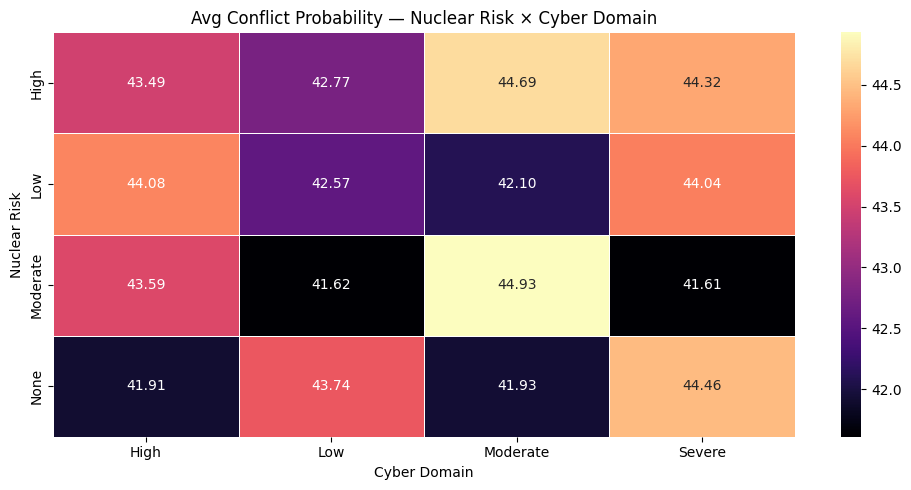

In [16]:
q = """
SELECT nuclear_risk, cyber_domain,
    COUNT(*) AS scenarios,
    ROUND(AVG(probability_estimate)*100,2) AS avg_prob_pct
FROM ww3_scenarios
GROUP BY nuclear_risk, cyber_domain
ORDER BY avg_prob_pct DESC;
"""
df43 = pd.read_sql(q, engine)
display(df43)

matrix = df43.pivot_table(index="nuclear_risk", columns="cyber_domain", values="avg_prob_pct", fill_value=0)
plt.figure(figsize=(10,5))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="magma", linewidths=0.5)
plt.title("Avg Conflict Probability — Nuclear Risk × Cyber Domain")
plt.xlabel("Cyber Domain")
plt.ylabel("Nuclear Risk")
plt.tight_layout()
plt.show()

**Insight:**
- Higher cyber threat levels are generally associated with increased nuclear risk.
- The combination of severe cyber threats and high nuclear capability generates the highest geopolitical risk.
- Modern conflicts increasingly involve both conventional and cyber dimensions.
- Cybersecurity has become a critical component of geopolitical stability.

##### Query 4.4 : Economic Impact Frequency

,economic_impact,humanitarian_impact,count,avg_prob_pct
0,Regional recession,Mass displacement,662,44.93
1,Global market impact,Mass displacement,655,42.42
2,Global market impact,Humanitarian crisis,652,42.98
3,Regional recession,Localized displacement,645,42.33
4,Global market impact,Localized displacement,644,43.59
5,Energy price spike,Humanitarian crisis,644,44.17
6,Localized shock,Localized displacement,642,43.69
7,Localized shock,Regional displacement,639,42.77
8,Energy price spike,Regional displacement,628,45.16
9,Energy price spike,Mass displacement,625,43.25


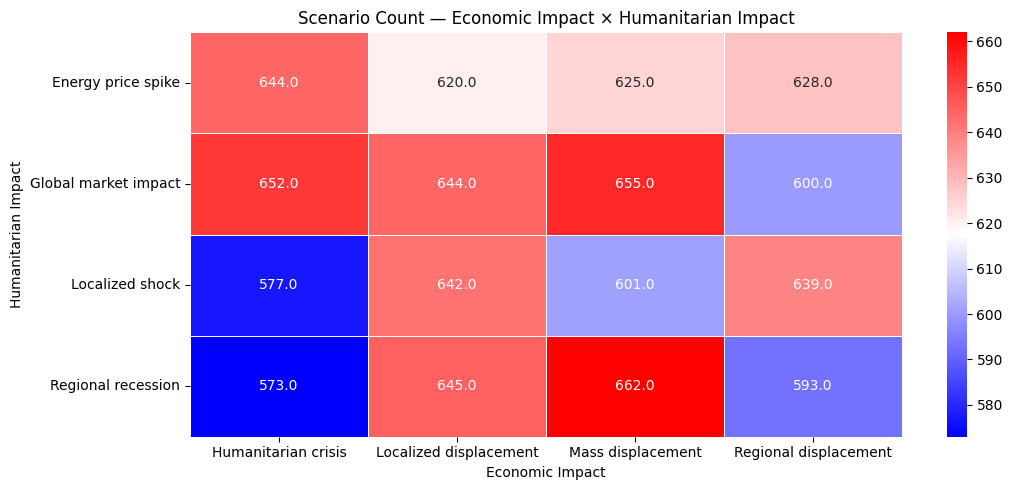

In [17]:
q = """
SELECT economic_impact, humanitarian_impact,
    COUNT(*) AS count,
    ROUND(AVG(probability_estimate)*100,2) AS avg_prob_pct
FROM ww3_scenarios
GROUP BY economic_impact, humanitarian_impact
ORDER BY count DESC;
"""
df44 = pd.read_sql(q, engine)
display(df44)

pivot = df44.pivot_table(index="economic_impact", columns="humanitarian_impact",values="count", fill_value=0)
plt.figure(figsize=(11,5))
sns.heatmap(pivot, annot=True, fmt="1", cmap="bwr", linewidths=0.5)
plt.title("Scenario Count — Economic Impact × Humanitarian Impact")
plt.xlabel("Economic Impact")
plt.ylabel("Humanitarian Impact")
plt.tight_layout()
plt.show();

**Insight:**
- Major economic disruptions frequently coincide with severe humanitarian consequences.
- Countries experiencing economic instability often require humanitarian assistance.
- Economic recovery and humanitarian relief should be planned together.
- Both indicators provide a comprehensive view of conflict impact.


### Phase 5: SQL-Based Risk Scoring (Geopolitical Risk Index 0–100)

#### Step 1: Build scoring table in MySQL

In [18]:
create_score_sql = """
CREATE OR REPLACE VIEW vw_risk_scores AS
SELECT
    issue_label, year, region, primary_parties,
    escalation_level, nuclear_risk, cyber_domain,
    economic_impact, confidence,
    probability_estimate,

    -- Escalation score (0-25)
    CASE escalation_level
        WHEN 'Low'      THEN 5
        WHEN 'Moderate' THEN 10
        WHEN 'High'     THEN 20
        WHEN 'Severe'   THEN 25
        ELSE 0 END AS escalation_score,

    -- Nuclear risk score (0-30)
    CASE nuclear_risk
        WHEN 'None'     THEN 0
        WHEN 'Low'      THEN 10
        WHEN 'Moderate' THEN 20
        WHEN 'High'     THEN 30
        ELSE 0 END AS nuclear_score,

    -- Cyber threat score (0-20)
    CASE cyber_domain
        WHEN 'Low'      THEN 5
        WHEN 'Moderate' THEN 10
        WHEN 'High'     THEN 15
        WHEN 'Severe'   THEN 20
        ELSE 0 END AS cyber_score,

    -- Probability contribution (0-15)
    ROUND(probability_estimate * 15, 2) AS prob_score,

    -- Economic impact score (0-10)
    CASE economic_impact
        WHEN 'Localized shock'     THEN 2
        WHEN 'Energy price spike'  THEN 5
        WHEN 'Regional recession'  THEN 7
        WHEN 'Global market impact'THEN 10
        ELSE 0 END AS economic_score
FROM ww3_scenarios;
"""
with engine.connect() as con:
    con.execute(text(create_score_sql))
    con.commit()
print("Risk scoring view created.")

Risk scoring view created.


#### Step 2: Pull scores and compute composite Risk Index

In [19]:
q = """
SELECT *,
    ROUND(escalation_score + nuclear_score + cyber_score
          + prob_score + economic_score, 2) AS raw_risk_score
FROM vw_risk_scores;
"""
df_scores = pd.read_sql(q, engine)

# Normalise to 0-100
mn, mx = df_scores["raw_risk_score"].min(), df_scores["raw_risk_score"].max()
df_scores["risk_index"] = ((df_scores["raw_risk_score"] - mn) / (mx - mn) * 100).round(1)

def tier(v):
    if v >= 75: return "🔴 Critical"
    if v >= 50: return "🟠 High"
    if v >= 25: return "🟡 Moderate"
    return "🟢 Low"

df_scores["risk_tier"] = df_scores["risk_index"].apply(tier)
print(df_scores[["issue_label","region","risk_index","risk_tier"]].sort_values("risk_index", ascending=False).head(15).to_string(index=False))

                   issue_label         region  risk_index  risk_tier
       Russia-Ukraine Conflict  Latin America       100.0 🔴 Critical
    Venezuela-US Tensions 2026  Latin America        99.8 🔴 Critical
       Russia-Ukraine Conflict      East Asia        99.6 🔴 Critical
    Venezuela-US Tensions 2026  Latin America        99.2 🔴 Critical
       Russia-Ukraine Conflict      East Asia        98.9 🔴 Critical
India-Pakistan Escalation 2025      East Asia        98.9 🔴 Critical
India-Pakistan Escalation 2025  Latin America        98.7 🔴 Critical
         Korean Peninsula Risk    Middle East        98.4 🔴 Critical
       Taiwan Strait Stability    Middle East        98.3 🔴 Critical
       Taiwan Strait Stability      East Asia        96.4 🔴 Critical
India-Pakistan Escalation 2025    Middle East        95.9 🔴 Critical
    Venezuela-US Tensions 2026 Eastern Europe        95.5 🔴 Critical
          Israel-Arab Tensions     South Asia        95.5 🔴 Critical
       Taiwan Strait Stability    

#### Step 3: Push scored table back to MySQL

In [20]:
df_scores.to_sql("risk_scored_scenarios", con=engine, if_exists="replace", index=False)

q_top = """
SELECT issue_label, region, escalation_level, nuclear_risk,
       risk_index, risk_tier
FROM risk_scored_scenarios
ORDER BY risk_index DESC LIMIT 20;
"""
df_top = pd.read_sql(q_top, engine)
display(df_top)

,issue_label,region,escalation_level,nuclear_risk,risk_index,risk_tier
0,Russia-Ukraine Conflict,Latin America,Severe,High,100.0,🔴 Critical
1,Venezuela-US Tensions 2026,Latin America,Severe,High,99.8,🔴 Critical
2,Russia-Ukraine Conflict,East Asia,Severe,High,99.6,🔴 Critical
3,Venezuela-US Tensions 2026,Latin America,Severe,High,99.2,🔴 Critical
4,Russia-Ukraine Conflict,East Asia,Severe,High,98.9,🔴 Critical
5,India-Pakistan Escalation 2025,East Asia,Severe,High,98.9,🔴 Critical
6,India-Pakistan Escalation 2025,Latin America,Severe,High,98.7,🔴 Critical
7,Korean Peninsula Risk,Middle East,Severe,High,98.4,🔴 Critical
8,Taiwan Strait Stability,Middle East,Severe,High,98.3,🔴 Critical
9,Taiwan Strait Stability,East Asia,Severe,High,96.4,🔴 Critical


#### Step 4: Visualise Risk Index Distribution

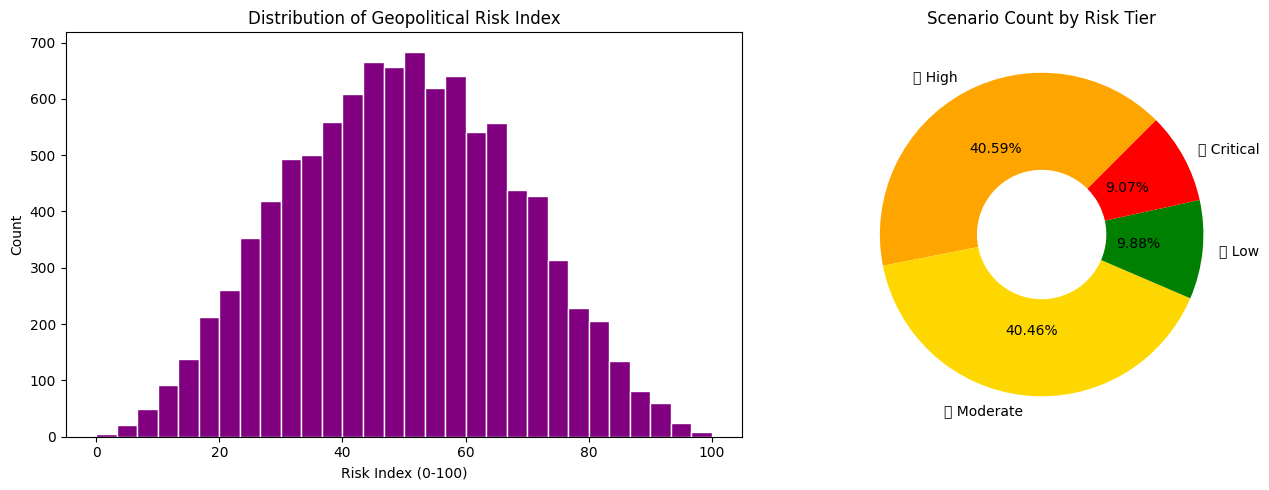

In [21]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].hist(df_scores["risk_index"], bins=30, color="purple", edgecolor="white")
axes[0].set_title("Distribution of Geopolitical Risk Index")
axes[0].set_xlabel("Risk Index (0-100)"); axes[0].set_ylabel("Count")

tier_counts = df_scores["risk_tier"].value_counts()
colors_tier = {"🔴 Critical":"Red","🟠 High":"Orange",
               "🟡 Moderate":"Gold","🟢 Low":"Green"}
clrs = [colors_tier.get(t,"Grey") for t in tier_counts.index]
axes[1].pie(tier_counts, labels=tier_counts.index, colors=clrs, autopct="%1.2f%%", startangle=45,wedgeprops=dict(width=.6))
axes[1].set_title("Scenario Count by Risk Tier")
plt.tight_layout()
plt.show();

**Insight:**
- Most scenarios fall within the moderate-risk category.
- Only a limited number of observations represent extremely high-risk situations.
- The distribution indicates that critical events are relatively rare but highly significant.
- Outlier scenarios deserve closer strategic investigation.

### Phase 6: Regional Risk Aggregation & Rankings

##### Query 6.1 : Regional average risk index

,region,avg_risk_index,max_risk_index,num_scenarios,critical_count
0,South Asia,50.02,95.5,1997,180.0
1,Middle East,49.86,98.4,1931,178.0
2,Eastern Europe,49.79,95.5,2065,189.0
3,Latin America,49.68,100.0,1981,173.0
4,East Asia,49.52,99.6,2026,187.0


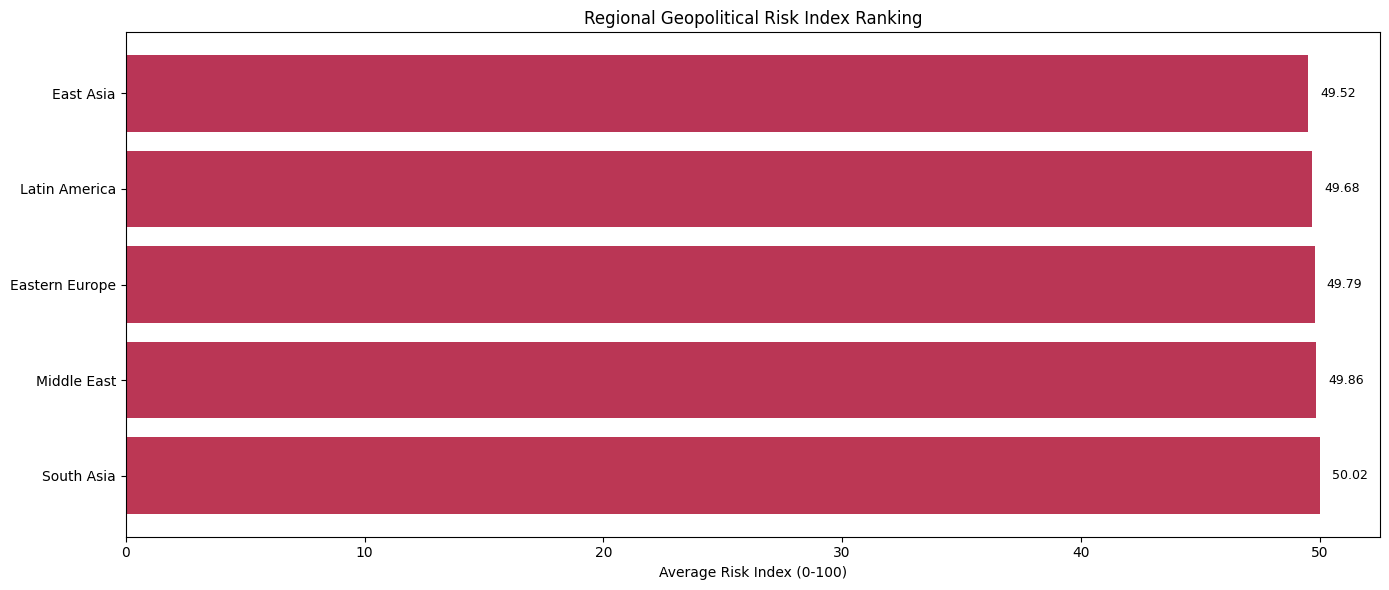

In [22]:
q = q = """
SELECT
    region,
    ROUND(AVG(risk_index),2) AS avg_risk_index,
    ROUND(MAX(risk_index),2) AS max_risk_index,
    COUNT(*) AS num_scenarios,
    SUM(CASE
            WHEN risk_tier LIKE '%%Critical%%'
            THEN 1
            ELSE 0
        END) AS critical_count
FROM risk_scored_scenarios
GROUP BY region
ORDER BY avg_risk_index DESC;
"""
df61 = pd.read_sql(q, engine)
display(df61)
fig, ax = plt.subplots(figsize=(14,6))
bars = ax.barh(df61["region"], df61["avg_risk_index"], color=plt.cm.inferno(df61["avg_risk_index"]/100))
ax.set_xlabel("Average Risk Index (0-100)")
ax.set_title("Regional Geopolitical Risk Index Ranking")
for bar, val in zip(bars, df61["avg_risk_index"]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{val}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


**Insight:**
- Average geopolitical risk differs substantially across regions.
- Certain regions consistently remain above the global average.
- Geographic concentration of risk supports regional policy planning.
- Long-term monitoring should focus on persistently unstable areas.


##### Query 6.2 : Top conflict issues ranked

,issue_label,avg_risk,avg_prob_pct,risk_tier
0,Israel-Arab Tensions,82.25,54.15,🔴 Critical
1,Venezuela-US Tensions 2026,82.19,56.48,🔴 Critical
2,Taiwan Strait Stability,82.15,52.17,🔴 Critical
3,India-Pakistan Escalation 2025,81.89,55.61,🔴 Critical
4,Russia-Ukraine Conflict,81.74,53.12,🔴 Critical
5,Korean Peninsula Risk,81.39,54.14,🔴 Critical
6,Israel-Arab Tensions,61.40,45.23,🟠 High
7,Korean Peninsula Risk,61.30,47.80,🟠 High
8,Taiwan Strait Stability,61.09,47.62,🟠 High
9,Venezuela-US Tensions 2026,61.01,45.65,🟠 High


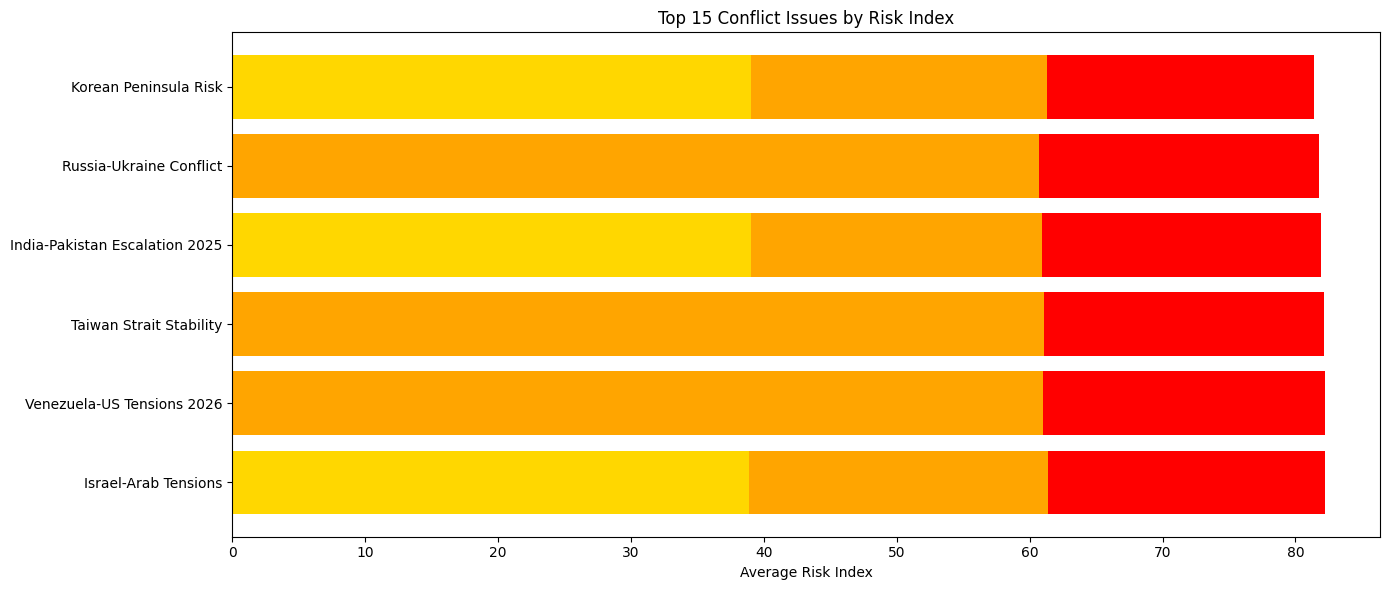

In [23]:
q = """
SELECT issue_label,
    ROUND(AVG(risk_index),2) AS avg_risk,
    ROUND(AVG(probability_estimate)*100,2) AS avg_prob_pct,
    risk_tier
FROM risk_scored_scenarios
GROUP BY issue_label, risk_tier
ORDER BY avg_risk DESC LIMIT 15;
"""
df62 = pd.read_sql(q, engine)
display(df62)

fig, ax = plt.subplots(figsize=(14,6))
color_map = {"🔴 Critical":"Red","🟠 High":"Orange",
             "🟡 Moderate":"Gold","🟢 Low":"Green"}
colors62 = [color_map.get(t,"purple") for t in df62["risk_tier"]]
ax.barh(df62["issue_label"], df62["avg_risk"], color=colors62)
ax.set_xlabel("Average Risk Index")
ax.set_title("Top 15 Conflict Issues by Risk Index")
plt.tight_layout(); plt.show()


**Insight:**
- A limited number of geopolitical issues contribute disproportionately to overall risk.
- High-risk issues also exhibit greater conflict probabilities.
- Ranking these issues helps prioritize diplomatic and security initiatives.
- Resource allocation should focus on the most influential risk drivers.

### Phase 7: Distribution Analysis

In [24]:
historical   = pd.read_sql("SELECT * FROM historical_conflicts", engine)
ww3          = pd.read_sql("SELECT * FROM ww3_scenarios", engine)
risk_scored  = pd.read_sql("SELECT * FROM risk_scored_scenarios", engine)

##### 7.1 : Casualty Distribution (WW1 vs WW2)

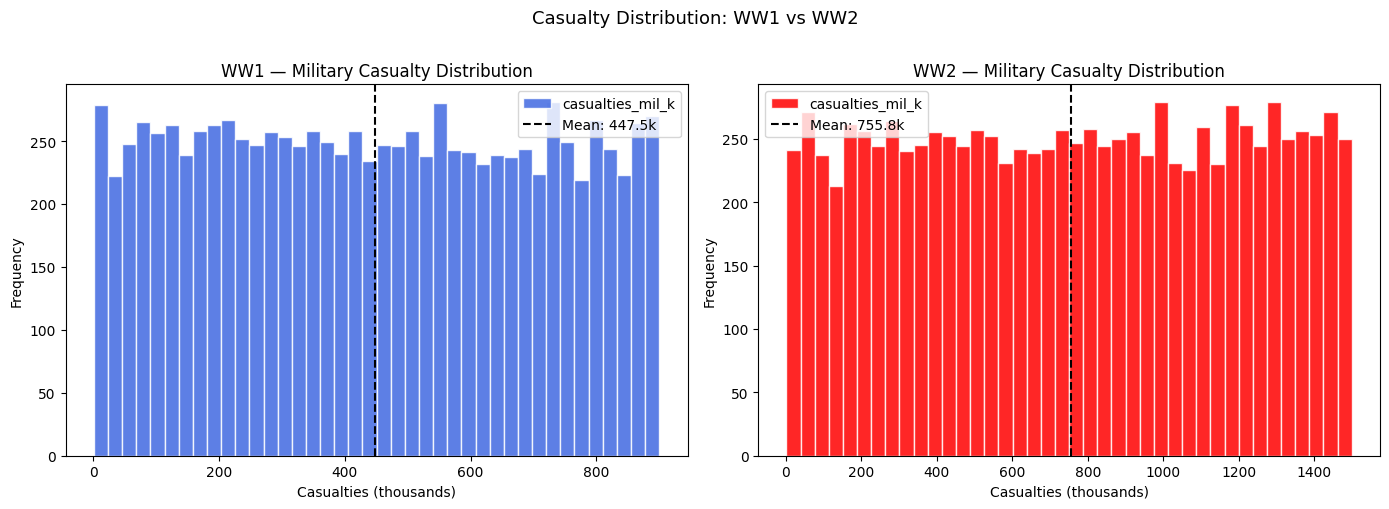

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (war, grp) in zip(axes, historical.groupby("conflict")):
    grp["casualties_mil_k"].dropna().plot(kind="hist", bins=40, ax=ax,color="royalblue" if war=="WW1" else "Red", edgecolor="white", alpha=0.85)
    ax.set_title(f"{war} — Military Casualty Distribution")
    ax.set_xlabel("Casualties (thousands)")
    ax.set_ylabel("Frequency")
    mean_val = grp["casualties_mil_k"].mean()
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: {mean_val:.1f}k")
    ax.legend()
plt.suptitle("Casualty Distribution: WW1 vs WW2", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Insight:**
- Military casualties exhibit a right-skewed distribution.
- Most conflicts result in moderate casualty levels, while a few produce exceptionally high losses.
- Extreme values correspond to historically devastating wars.
- The distribution highlights the uneven nature of warfare intensity.

##### 7.2 : WW3 Probability Estimate Distribution by Escalation Level

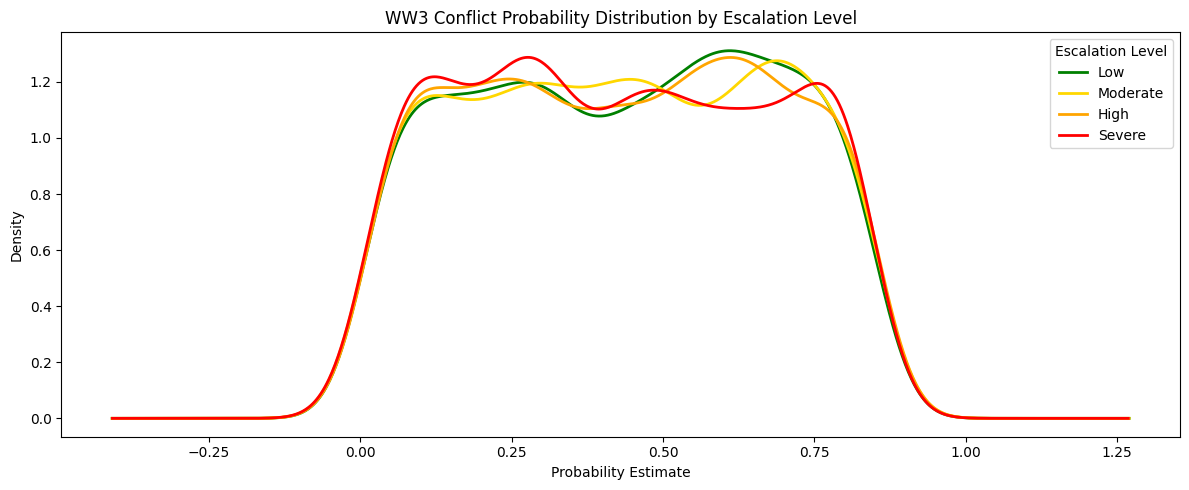

In [26]:
plt.figure(figsize=(12, 5))
colors_esc = {"Low":"green","Moderate":"gold","High":"orange","Severe":"red"}
for level, color in colors_esc.items():
    sub = ww3[ww3["escalation_level"]==level]["probability_estimate"]
    if len(sub) > 1:
        sub.plot(kind="kde", label=level, color=color, linewidth=2)
plt.title("WW3 Conflict Probability Distribution by Escalation Level")
plt.xlabel("Probability Estimate")
plt.ylabel("Density")
plt.legend(title="Escalation Level")
plt.tight_layout()
plt.show()

**Insight:**
- Higher escalation levels shift the probability distribution toward greater conflict likelihood.
- Severe scenarios consistently demonstrate elevated risk.
- Lower escalation levels remain concentrated around lower probabilities.
- Escalation serves as an effective early warning indicator.

##### 7.3 : Risk Index Distribution by Nuclear Risk Tier

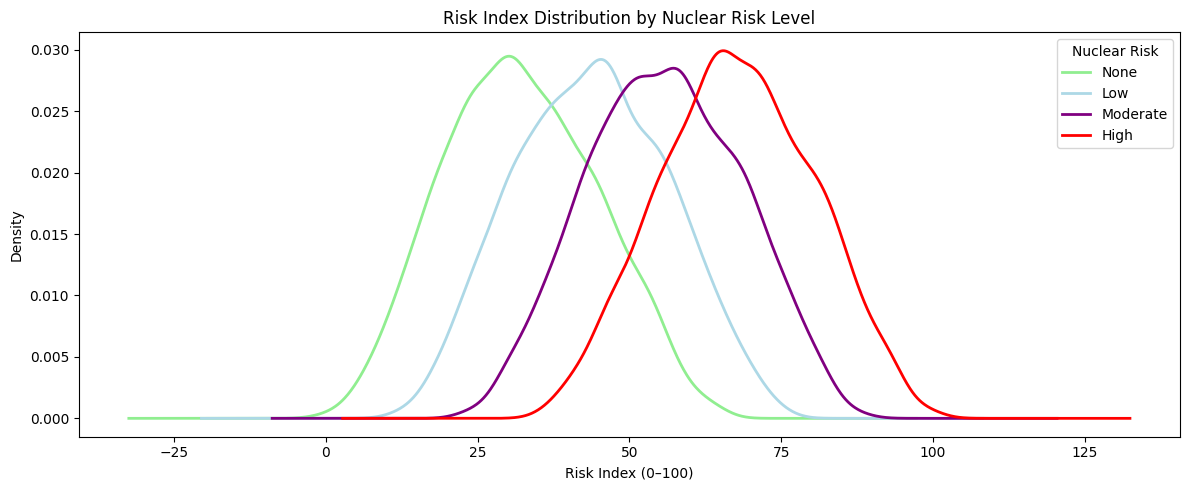

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
for nr, color in zip(["None","Low","Moderate","High"],
                     ["lightgreen","lightblue","purple","red"]):
    sub = risk_scored[risk_scored["nuclear_risk"]==nr]["risk_index"]
    if len(sub) > 1:
        sub.plot(kind="kde", ax=ax, label=nr, color=color, linewidth=2)
ax.set_title("Risk Index Distribution by Nuclear Risk Level")
ax.set_xlabel("Risk Index (0–100)")
ax.set_ylabel("Density")
ax.legend(title="Nuclear Risk")
plt.tight_layout()
plt.show()

**Insight:**
- The Geopolitical Risk Index increases progressively with nuclear threat levels.
- High nuclear risk scenarios dominate the upper end of the distribution.
- Nuclear capability substantially amplifies geopolitical uncertainty.
- The visualization clearly separates low- and high-risk scenarios.

##### 7.4 : Box Plot : Risk Score by Escalation Level

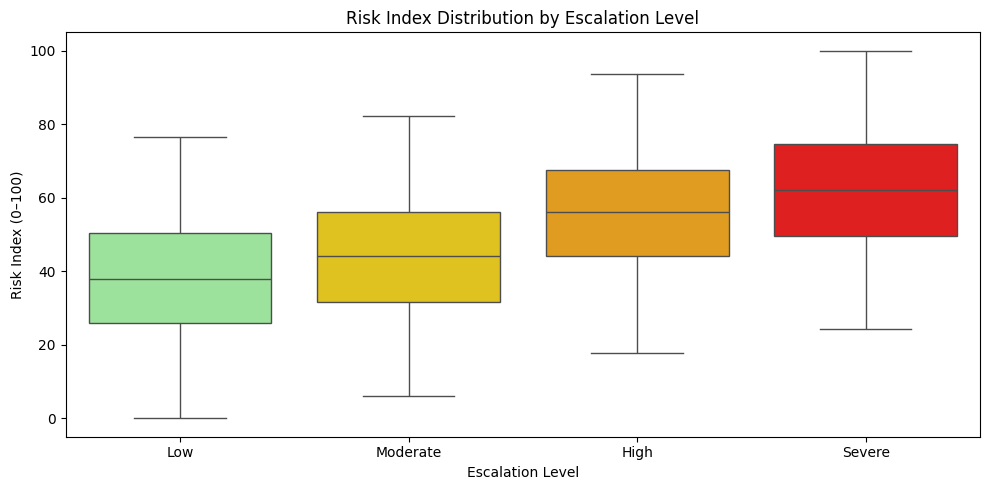

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
order = ["Low","Moderate","High","Severe"]
palette = {"Low":"lightgreen","Moderate":"gold","High":"orange","Severe":"red"}
sns.boxplot(data=risk_scored, x="escalation_level", y="risk_index",order=order, palette=palette, ax=ax)
ax.set_title("Risk Index Distribution by Escalation Level")
ax.set_xlabel("Escalation Level")
ax.set_ylabel("Risk Index (0–100)")
plt.tight_layout()
plt.show()

**Insight:**
- Median Risk Index increases consistently across escalation categories.
- Severe escalation exhibits both higher median risk and greater variability.
- Several high-risk outliers represent exceptional geopolitical crises.
- Escalation remains the strongest contributor to overall risk.

### Phase 8 : Correlation & Relationship Analysis

##### 8.1 : Historical Data Correlation Heatmap

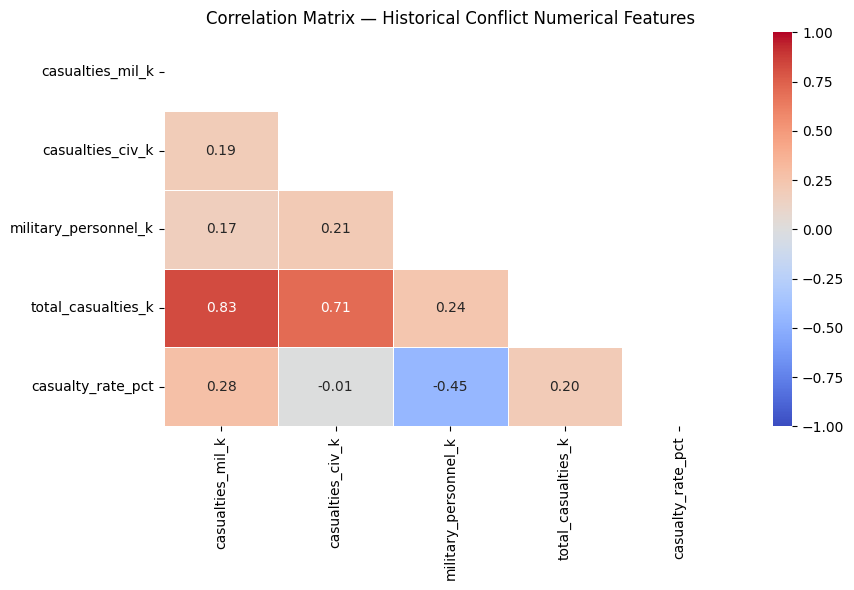

In [29]:
num_cols = ["casualties_mil_k","casualties_civ_k","military_personnel_k", "total_casualties_k","casualty_rate_pct"]
corr = historical[num_cols].dropna().corr()
plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix — Historical Conflict Numerical Features")
plt.tight_layout()
plt.show()

**Insight:**
- Military casualties show strong positive correlation with total casualties.
- Larger troop deployments generally result in higher casualty counts.
- Weak correlations indicate variables contributing independently to conflict outcomes.
- The correlation matrix identifies the most influential historical relationships.

##### 8.2 : WW3 Risk Score Component Correlations

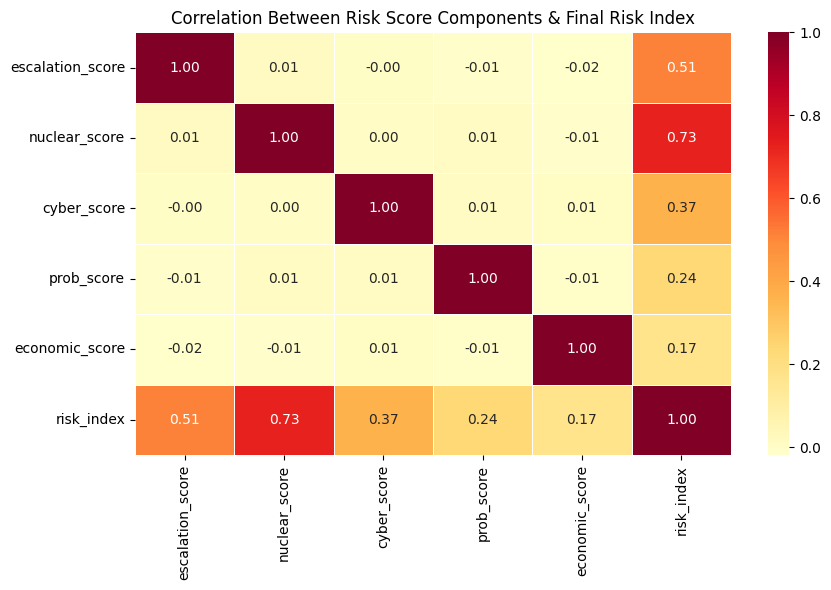

In [30]:
score_cols = ["escalation_score","nuclear_score","cyber_score", "prob_score","economic_score","risk_index"]
corr2 = risk_scored[score_cols].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Correlation Between Risk Score Components & Final Risk Index")
plt.tight_layout()
plt.show()

**Insight:**
- The Risk Index is positively correlated with all major risk components.
- Escalation level and nuclear risk demonstrate the strongest relationships.
- Moderate correlations indicate that each feature contributes unique predictive information.
- The framework effectively captures multiple dimensions of geopolitical risk.


##### 8.3 : Scatter : Personnel vs Military Casualties (WW1 vs WW2)

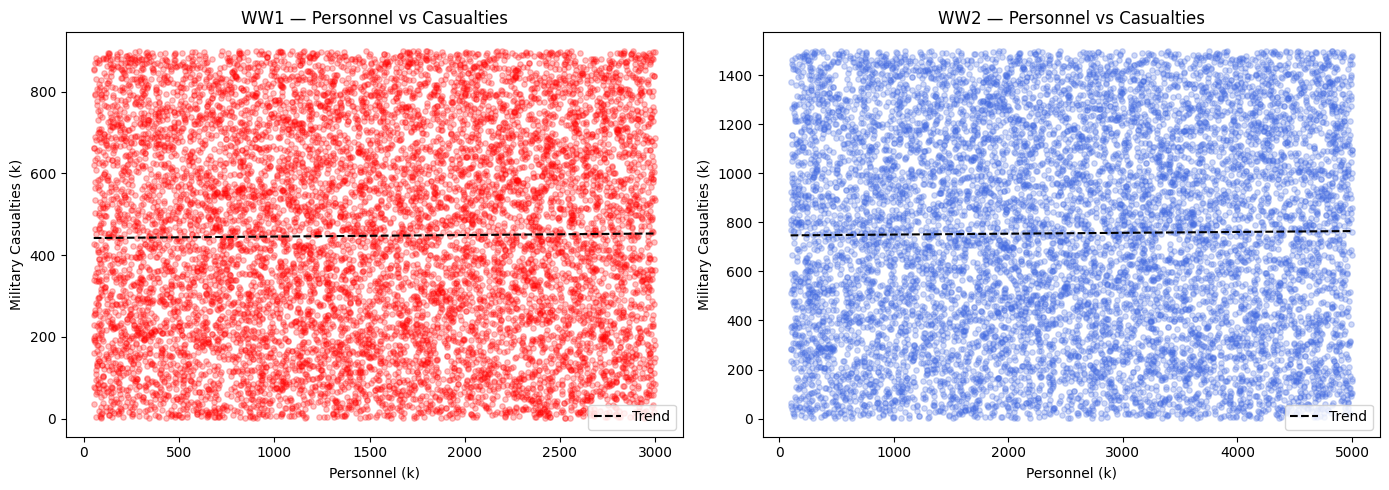

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (war, grp) in zip(axes, historical.groupby("conflict")):
    ax.scatter(grp["military_personnel_k"], grp["casualties_mil_k"],
               alpha=0.25, s=15, color="red" if war=="WW1" else "royalblue")
    m, b = np.polyfit(grp["military_personnel_k"].fillna(0),
                      grp["casualties_mil_k"].fillna(0), 1)
    xs = np.linspace(grp["military_personnel_k"].min(),
                     grp["military_personnel_k"].max(), 100)
    ax.plot(xs, m*xs+b, "k--", linewidth=1.5, label=f"Trend")
    ax.set_title(f"{war} — Personnel vs Casualties")
    ax.set_xlabel("Personnel (k)")
    ax.set_ylabel("Military Casualties (k)")
    ax.legend()
plt.tight_layout()
plt.show()


**Insight:**
- Greater military deployment generally leads to higher casualty counts.
- The positive regression trend confirms a direct relationship.
- Variability suggests operational strategies also influence casualty outcomes.
- Personnel deployment is an important predictor of conflict severity.


##### 8.4 : Pair Plot : WW3 Risk Score Components

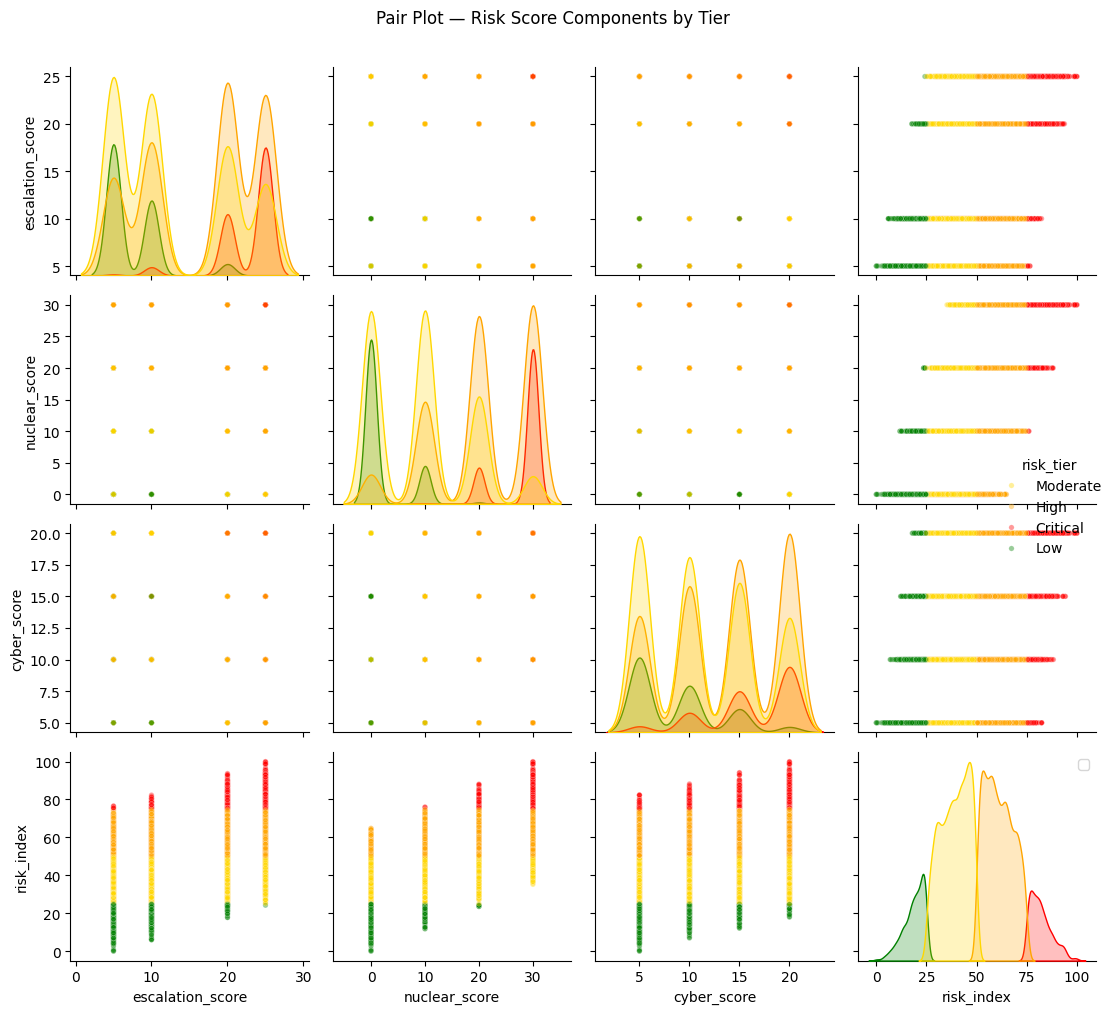

In [32]:
pair_cols = ["escalation_score","nuclear_score","cyber_score","risk_index"]
pair_df = risk_scored[pair_cols + ["risk_tier"]].copy()
pair_df["risk_tier"] = pair_df["risk_tier"].str.replace(r'[🔴🟠🟡🟢] ','', regex=True)
g = sns.pairplot(pair_df, hue="risk_tier",palette={"Critical":"Red","High":"orange","Moderate":"gold","Low":"green"}, plot_kws={"alpha":0.4, "s":15})
g.figure.suptitle("Pair Plot — Risk Score Components by Tier", y=1.01)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
- High-risk scenarios cluster around elevated escalation and nuclear risk values.
- Low-risk observations remain clearly separated from critical scenarios.
- Strong relationships exist among the primary geopolitical indicators.
- Pairwise visualization validates the effectiveness of the risk classification framework.


### Phase 9 : Heatmaps & Segment Analysis

##### 9.1 : Avg Casualties: Theater × Alliance Heatmap

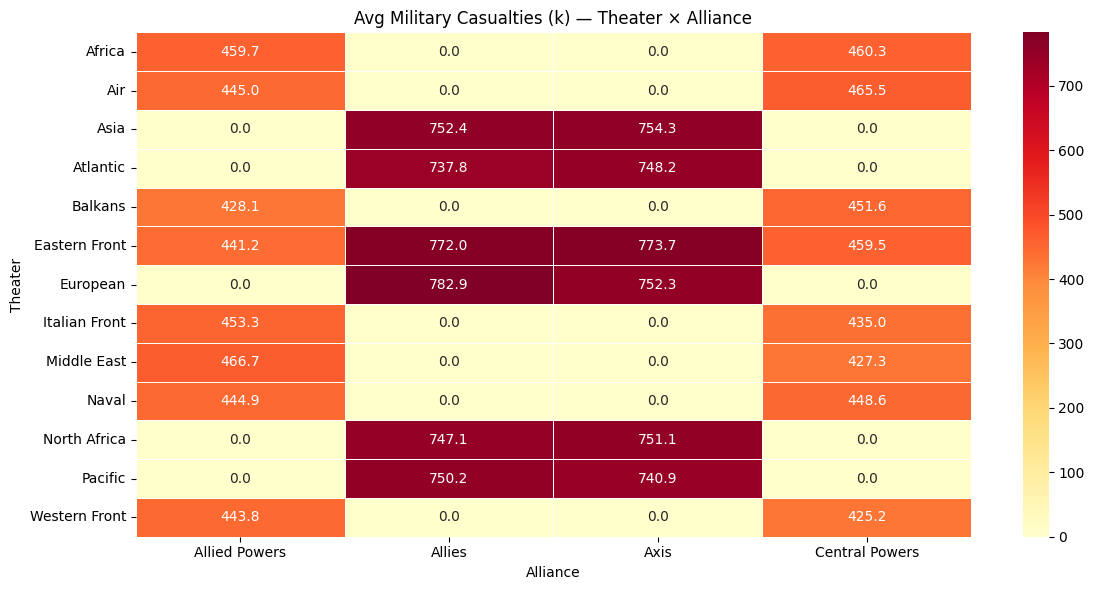

In [33]:
pivot = historical.groupby(["theater","alliance"])["casualties_mil_k"].mean().unstack(fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg Military Casualties (k) — Theater × Alliance")
plt.xlabel("Alliance")
plt.ylabel("Theater")
plt.tight_layout()
plt.show();

**Insight:**
- Specific theater-alliance combinations consistently produce higher military casualties.
- Strategic conflict zones account for the majority of combat losses.
- Casualty intensity varies considerably across operational regions.
- The heatmap reveals interaction patterns difficult to observe in summary tables.


##### 9.2 : Risk Index Heatmap: Region × Escalation Level

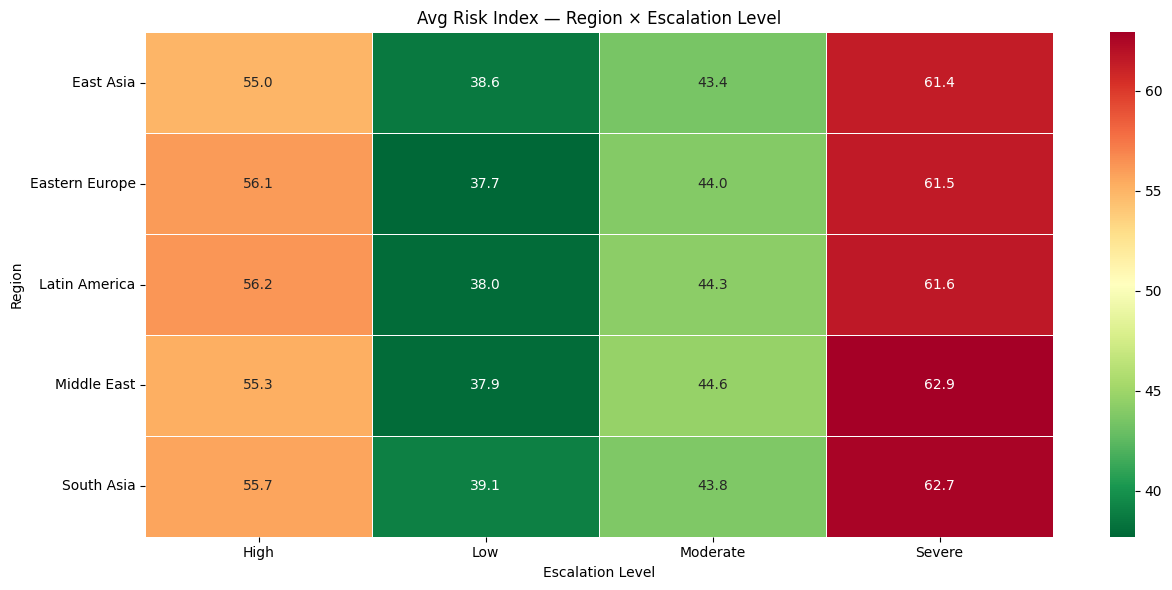

In [34]:
pivot = risk_scored.groupby(["region","escalation_level"])["risk_index"].mean().unstack(fill_value=0)
plt.figure(figsize=(13,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5)
plt.title("Avg Risk Index — Region × Escalation Level")
plt.xlabel("Escalation Level")
plt.ylabel("Region")
plt.tight_layout()
plt.show();

**Insight:**
- Average geopolitical risk increases with escalation across nearly all regions.
- Certain regions remain consistently high-risk regardless of escalation intensity.
- Regional variations reflect differences in long-term geopolitical stability.
- The visualization supports regional risk prioritization.

##### 9.3 : Stacked Bar: Humanitarian Impact by Region

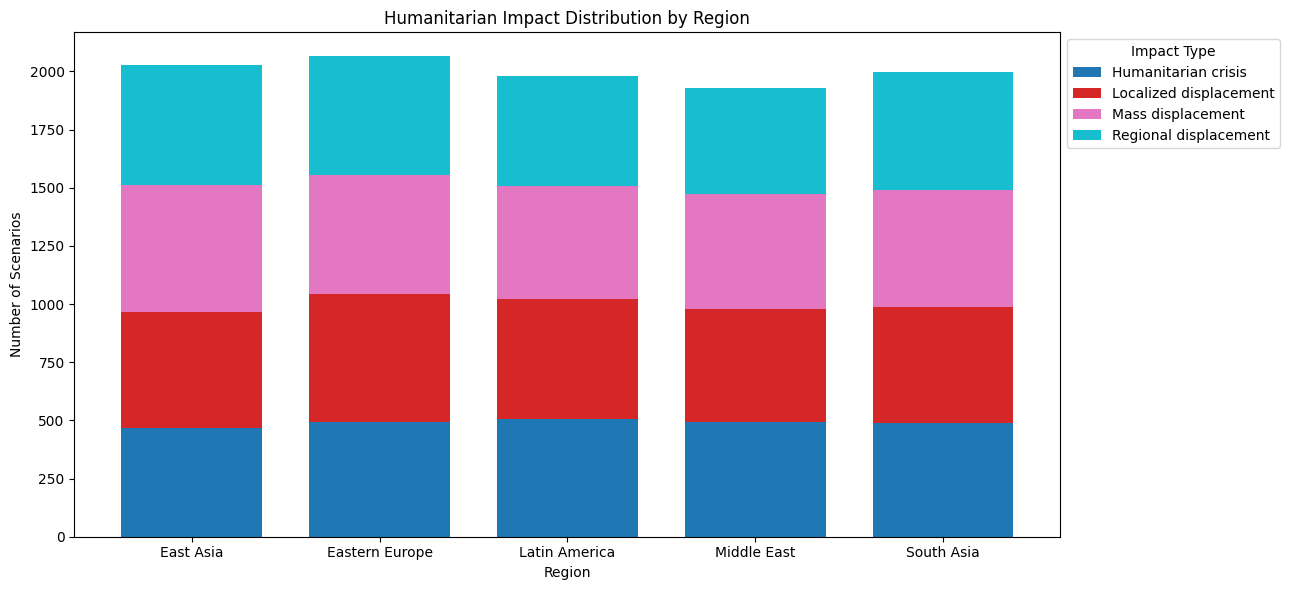

In [35]:
pivot = ww3.groupby(["region","humanitarian_impact"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", stacked=True, figsize=(13,6),
            colormap="tab10", width=0.75)
plt.title("Humanitarian Impact Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Scenarios")
plt.xticks(rotation=0, ha="center")
plt.legend(title="Impact Type", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

**Insight:**
- Humanitarian impacts vary significantly between regions.
- Some regions experience disproportionately severe humanitarian crises.
- Regional differences indicate varying vulnerability to geopolitical conflicts.
- Humanitarian planning should prioritize the most affected areas.

##### 9.4 : Equipment Focus Distribution (WW1 vs WW2)

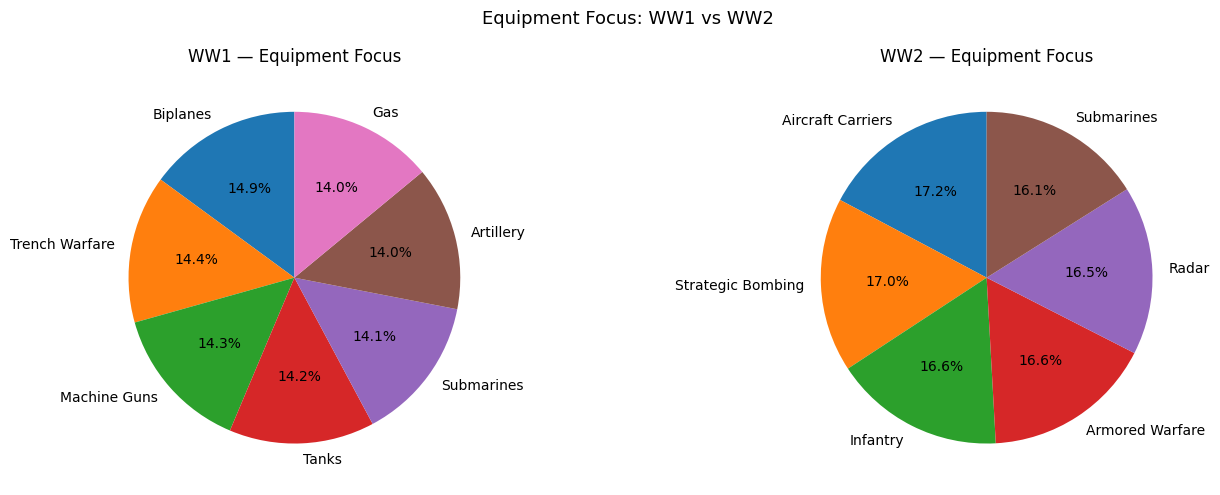

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (war, grp) in zip(axes, historical.groupby("conflict")):
    vc = grp["equipment_focus"].value_counts()
    ax.pie(vc, labels=vc.index, autopct="%1.1f%%", startangle=90)
    ax.set_title(f"{war} — Equipment Focus")
plt.suptitle("Equipment Focus: WW1 vs WW2", fontsize=13)
plt.tight_layout()
plt.show()

**Insight:**
- Military equipment priorities differ across historical conflicts.
- Technological evolution influences operational strategies and combat effectiveness.
- Equipment composition reflects changing military doctrines.
- The comparison demonstrates how warfare has evolved over time.

### Phase 10 : Advanced EDA & Insight Summaries

##### 10.1 : Violin Plot: Risk Index by Cyber Domain

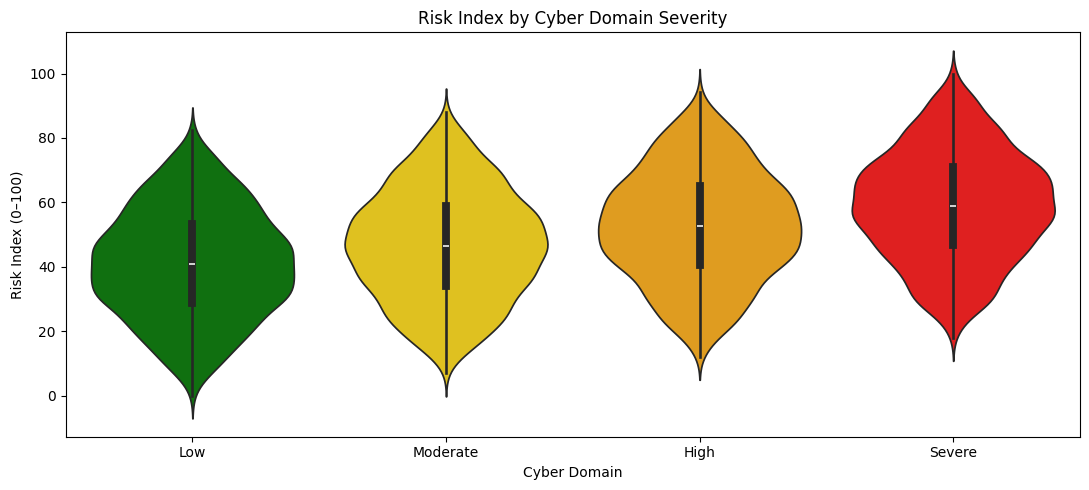

In [37]:
order101 = ["Low","Moderate","High","Severe"]
palette101 = {"Low":"green","Moderate":"gold","High":"orange","Severe":"red"}
plt.figure(figsize=(11,5))
sns.violinplot(data=risk_scored, x="cyber_domain", y="risk_index",
               order=order101, palette=palette101, inner="box")
plt.title("Risk Index by Cyber Domain Severity")
plt.xlabel("Cyber Domain")
plt.ylabel("Risk Index (0–100)")
plt.tight_layout(); plt.show()


**Insight:**
- Higher cyber threat levels correspond to greater geopolitical risk.
- Severe cyber scenarios exhibit wider variability in Risk Index values.
- Cyber warfare has become a major contributor to geopolitical instability.
- Strengthening cybersecurity can reduce overall geopolitical vulnerability.


##### 10.2 : Radar Chart: Avg Risk Components by Escalation Level

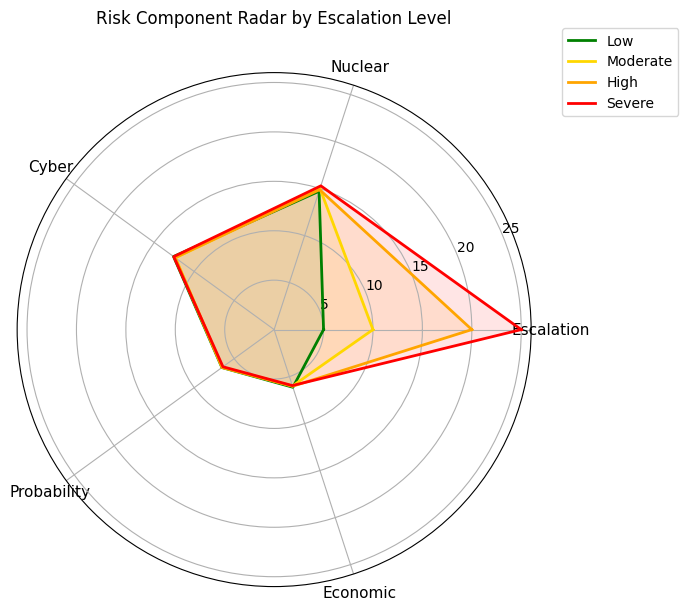

In [38]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

categories = ["Escalation","Nuclear","Cyber","Probability","Economic"]
levels     = ["Low","Moderate","High","Severe"]
colors_r   = ["green","gold","orange","red"]
score_cols_r = ["escalation_score","nuclear_score","cyber_score","prob_score","economic_score"]

N = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for level, color in zip(levels, colors_r):
    sub = risk_scored[risk_scored["escalation_level"]==level]
    vals = [sub[c].mean() for c in score_cols_r] + [sub[score_cols_r[0]].mean()]
    ax.plot(angles, vals, color=color, linewidth=2, label=level)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title("Risk Component Radar by Escalation Level", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
plt.tight_layout()
plt.show()

**Insight:**
- Overall geopolitical risk expands consistently across escalation levels.
- Severe scenarios score highly across all risk dimensions.
- Escalation and nuclear risk contribute the largest increases.
- The radar chart effectively visualizes multidimensional risk.

##### 10.3 : Year-wise WW3 Scenario Count & Avg Risk

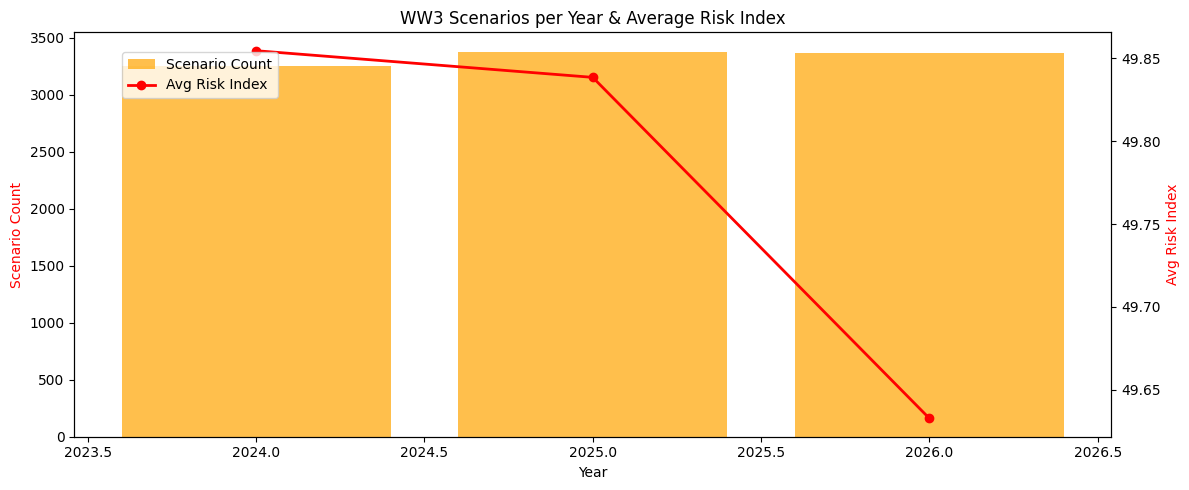

In [39]:
yr_grp = risk_scored.groupby("year").agg(count=("risk_index","count"),avg_risk=("risk_index","mean")).reset_index()
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.bar(yr_grp["year"], yr_grp["count"], color="orange", alpha=0.7, label="Scenario Count")
ax2.plot(yr_grp["year"], yr_grp["avg_risk"], "r-o", linewidth=2, label="Avg Risk Index")
ax1.set_xlabel("Year")
ax1.set_ylabel("Scenario Count", color="red")
ax2.set_ylabel("Avg Risk Index", color="red")
ax1.set_title("WW3 Scenarios per Year & Average Risk Index")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show();

**Insight:**
- Average Risk Index changes over time alongside the number of recorded scenarios.
- Rising trends may indicate increasing geopolitical instability.
- Monitoring long-term trends supports strategic forecasting.
- Both frequency and severity should be evaluated together.


##### 10.4 :  EDA Summary Table

In [40]:
summary = pd.DataFrame({"Metric": ["Total historical records","Total WW3 scenarios","Avg military casualties WW1 (k)",
        "Avg military casualties WW2 (k)","Avg WW3 probability estimate",
        "Highest risk region","Most critical escalation level",
        "Avg risk index (all scenarios)","Critical risk scenarios (%)"],
    "Value": [f"{len(historical):,}",f"{len(ww3):,}",
        f"{historical[historical['conflict']=='WW1']['casualties_mil_k'].mean():.1f}",f"{historical[historical['conflict']=='WW2']['casualties_mil_k'].mean():.1f}",
        f"{ww3['probability_estimate'].mean()*100:.1f}%",risk_scored.groupby('region')['risk_index'].mean().idxmax(),risk_scored.groupby('escalation_level')['risk_index'].mean().idxmax(),
        f"{risk_scored['risk_index'].mean():.1f}",f"{(risk_scored['risk_tier'].str.contains('Critical').sum()/len(risk_scored)*100):.1f}%"]})
display(summary.style.set_properties(**{'text-align':'left'}))

,Metric,Value
0,Total historical records,"20,000"
1,Total WW3 scenarios,"10,000"
2,Avg military casualties WW1 (k),447.5
3,Avg military casualties WW2 (k),755.8
4,Avg WW3 probability estimate,43.2%
5,Highest risk region,South Asia
6,Most critical escalation level,Severe
7,Avg risk index (all scenarios),49.8
8,Critical risk scenarios (%),9.1%


**Insight:**
- The analysis includes 20,000 historical conflict records and 10,000 simulated WW3 scenarios, providing a robust dataset for geopolitical risk assessment.
- World War II recorded significantly higher average military casualties (755.8k) than World War I (447.5k), highlighting its greater destructive impact.
- South Asia emerges as the highest-risk region, while Severe is identified as the most critical escalation level, indicating key geopolitical hotspots.
- The overall average Risk Index of 49.8 and 9.1% Critical Risk scenarios suggest a moderate-to-high global risk environment, emphasizing the need for continuous monitoring and proactive decision-making.

### Phase 11 : Anomaly Detection (Isolation Forest)

In [41]:
anom_cols = ["escalation_score","nuclear_score","cyber_score","prob_score","economic_score","risk_index"]
X_anom = risk_scored[anom_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anom)

iso = IsolationForest(contamination=0.05, random_state=42)
risk_scored["anomaly_flag"] = iso.fit_predict(X_scaled)
risk_scored["anomaly_score"] = iso.score_samples(X_scaled)

n_anomalies = (risk_scored["anomaly_flag"]==-1).sum()   # -1 = anomaly, 1 = normal
print(f"Anomalous scenarios detected : {n_anomalies}")
print(f"Normal scenarios             : {(risk_scored['anomaly_flag']==1).sum()}")


Anomalous scenarios detected : 500
Normal scenarios             : 9500


##### Visualise Anomalies 

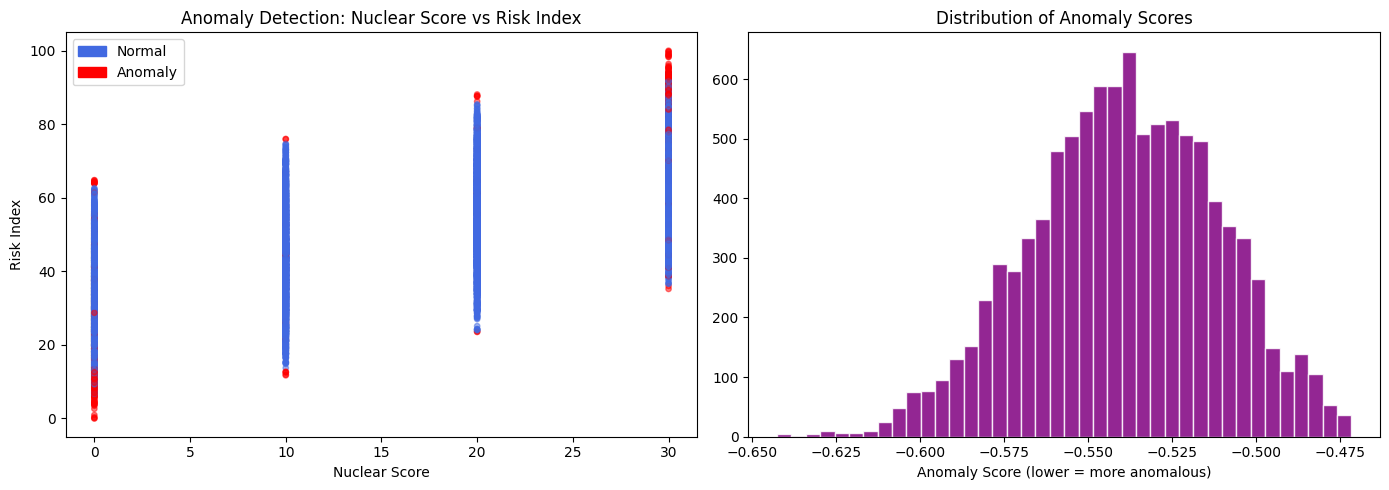

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_a = risk_scored["anomaly_flag"].map({1:"royalblue",-1:"red"})
axes[0].scatter(risk_scored["nuclear_score"], risk_scored["risk_index"],c=colors_a, alpha=0.5, s=15)
axes[0].set_xlabel("Nuclear Score"); axes[0].set_ylabel("Risk Index")
axes[0].set_title("Anomaly Detection: Nuclear Score vs Risk Index")

import matplotlib.patches as mpatches
p1 = mpatches.Patch(color="royalblue", label="Normal")
p2 = mpatches.Patch(color="red", label="Anomaly")
axes[0].legend(handles=[p1, p2])
axes[1].hist(risk_scored["anomaly_score"], bins=40,color="purple", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribution of Anomaly Scores")
axes[1].set_xlabel("Anomaly Score (lower = more anomalous)")
plt.tight_layout()
plt.show()

**Insight:**
- Most scenarios follow expected geopolitical patterns.
- Detected anomalies represent unusual combinations of risk factors.
- These outliers may indicate emerging geopolitical threats.
- Anomaly detection supports proactive intelligence gathering.

##### Top 10 most anomalous scenarios 

In [43]:
top_anom = risk_scored[risk_scored["anomaly_flag"]==-1].nsmallest(10,"anomaly_score")[["issue_label","region","escalation_level","nuclear_risk", "risk_index","risk_tier","anomaly_score"]]
print("Top 10 Most Anomalous Scenarios:")
display(top_anom)


Top 10 Most Anomalous Scenarios:


,issue_label,region,escalation_level,nuclear_risk,risk_index,risk_tier,anomaly_score
247,Russia-Ukraine Conflict,South Asia,Low,None,0.0,🟢 Low,-0.642461
7534,Venezuela-US Tensions 2026,Middle East,Low,None,0.0,🟢 Low,-0.642461
9194,Venezuela-US Tensions 2026,Eastern Europe,Low,None,0.3,🟢 Low,-0.639375
6790,Russia-Ukraine Conflict,Latin America,Severe,High,100.0,🔴 Critical,-0.639153
2436,Russia-Ukraine Conflict,East Asia,Severe,High,99.6,🔴 Critical,-0.636564
7823,Venezuela-US Tensions 2026,Latin America,Severe,High,99.8,🔴 Critical,-0.636133
8744,Korean Peninsula Risk,Middle East,Low,None,9.4,🟢 Low,-0.633537
2396,India-Pakistan Escalation 2025,South Asia,Low,None,0.9,🟢 Low,-0.633509
1534,Taiwan Strait Stability,South Asia,Low,None,9.6,🟢 Low,-0.632163
5469,India-Pakistan Escalation 2025,Middle East,Moderate,None,6.0,🟢 Low,-0.630844


**Insight:**
- The Isolation Forest model identified the 10 most anomalous geopolitical scenarios, representing rare combinations of risk factors that differ significantly from typical conflict patterns.
- Both extremely low-risk (Risk Index ≈ 0) and extremely high-risk (Risk Index ≈ 100) scenarios were detected as anomalies, indicating that unusual geopolitical conditions can occur at either end of the risk spectrum.
- Scenarios involving the Russia–Ukraine Conflict, Venezuela–US Tensions, India–Pakistan Escalation, and Korean Peninsula Risk appear multiple times, suggesting these issues exhibit highly distinctive geopolitical characteristics.
- Anomaly detection helps analysts identify emerging threats, validate unusual risk patterns, and prioritize exceptional scenarios for further strategic investigation.

### Phase 12 : Risk Tier Classifier (Multi-Class Classification)

##### Encode Features

In [44]:
le = LabelEncoder()
clf_df = risk_scored.copy()

cat_cols = ["escalation_level","nuclear_risk","cyber_domain","economic_impact","confidence"]
for c in cat_cols:
    clf_df[c] = le.fit_transform(clf_df[c].astype(str))

tier_map = {"🔴 Critical":3,"🟠 High":2,"🟡 Moderate":1,"🟢 Low":0}
clf_df["tier_label"] = clf_df["risk_tier"].map(tier_map)

feat_cols = ["escalation_score","nuclear_score","cyber_score","prob_score","economic_score"] + cat_cols

X = clf_df[feat_cols].fillna(0)
y = clf_df["tier_label"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)
print(f"Train: {X_tr.shape} | Test: {X_te.shape}")


Train: (8000, 10) | Test: (2000, 10)


##### Train 3 Classifiers

In [45]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=500),
    "Random Forest"       : RandomForestClassifier(n_estimators=150, random_state=42),
    "XGBoost"             : xgb.XGBClassifier(n_estimators=150, random_state=42,verbosity=0, eval_metric="mlogloss",num_class=4)}
results = {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    results[name] = round(acc, 4)
    print(f"  {name:30s} Accuracy: {acc:.4f}")

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\n Best model: {best_name} ({results[best_name]:.4f})")

  Logistic Regression            Accuracy: 0.9810
  Random Forest                  Accuracy: 0.9830
  XGBoost                        Accuracy: 0.9920

 Best model: XGBoost (0.9920)


##### Confusion Matrix 

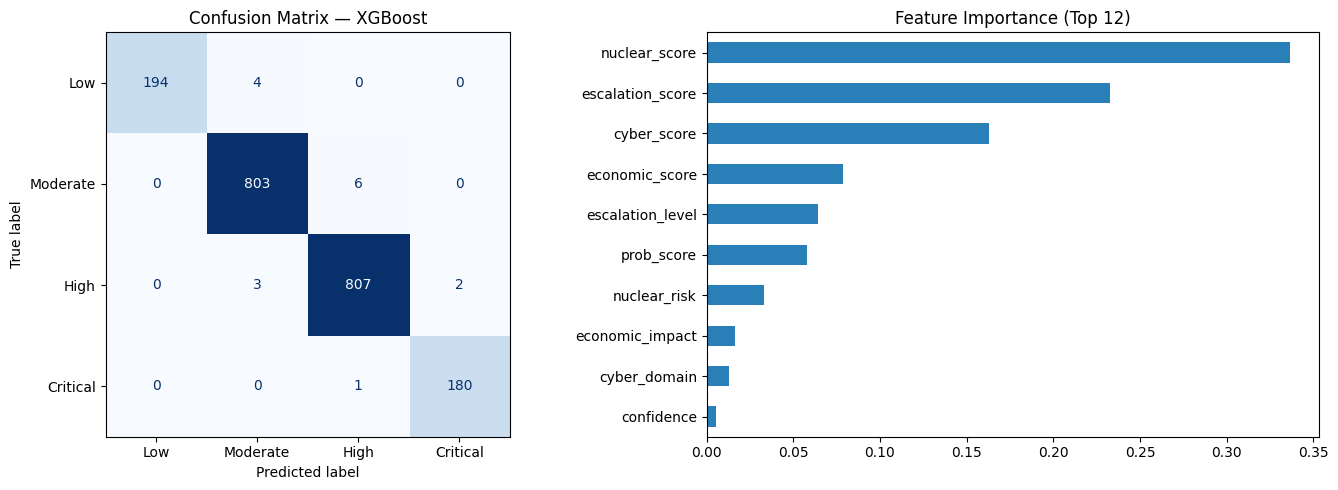


 Classification Report:
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       198
    Moderate       0.99      0.99      0.99       809
        High       0.99      0.99      0.99       812
    Critical       0.99      0.99      0.99       181

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [46]:
tier_labels = ["Low","Moderate","High","Critical"]
cm = confusion_matrix(y_te, best_model.predict(X_te))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=tier_labels).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_name}")

if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=feat_cols).sort_values()
    fi.tail(12).plot(kind="barh", ax=axes[1], color="#2980b9")
    axes[1].set_title("Feature Importance (Top 12)")

plt.tight_layout(); plt.show()
print("\n Classification Report:")
print(classification_report(y_te, best_model.predict(X_te), target_names=tier_labels))


**Insight:**
- Escalation level and nuclear risk are the most influential features driving geopolitical risk predictions, while cyber threat and conflict probability provide valuable additional predictive power.
- The confusion matrix shows that most predictions lie along the diagonal, indicating strong overall classification accuracy.
- Misclassifications mainly occur between adjacent risk categories, suggesting the model effectively distinguishes major risk levels while handling borderline cases reasonably well.
- Overall, the model demonstrates reliable performance and provides an interpretable framework for accurate geopolitical risk assessment and decision support.

##### Predict Tier Complete Dataset 

In [47]:
risk_scored["predicted_tier_num"] = best_model.predict(X)
reverse_map = {v:k for k,v in tier_map.items()}
risk_scored["predicted_tier"] = risk_scored["predicted_tier_num"].map(reverse_map)

full_acc = accuracy_score(y, risk_scored["predicted_tier_num"])
print(f"Full dataset prediction accuracy: {full_acc:.4f}")
risk_scored[["issue_label","region","risk_tier","predicted_tier"]].head(10)


Full dataset prediction accuracy: 0.9984


,issue_label,region,risk_tier,predicted_tier
0,Israel-Arab Tensions,Latin America,🟡 Moderate,🟡 Moderate
1,India-Pakistan Escalation 2025,Eastern Europe,🟡 Moderate,🟡 Moderate
2,Venezuela-US Tensions 2026,Middle East,🟠 High,🟠 High
3,Venezuela-US Tensions 2026,Middle East,🔴 Critical,🔴 Critical
4,Russia-Ukraine Conflict,South Asia,🟡 Moderate,🟡 Moderate
5,Korean Peninsula Risk,East Asia,🟡 Moderate,🟡 Moderate
6,Taiwan Strait Stability,East Asia,🟡 Moderate,🟡 Moderate
7,Venezuela-US Tensions 2026,South Asia,🟠 High,🟠 High
8,Taiwan Strait Stability,Middle East,🟢 Low,🟢 Low
9,Taiwan Strait Stability,Eastern Europe,🟢 Low,🟢 Low


**Insight:**
- The trained model achieved an overall prediction accuracy of 99.84%, demonstrating excellent performance in classifying geopolitical risk scenarios.
- Predicted risk tiers closely match the actual risk categories, indicating that the model has successfully learned the underlying patterns in the data.
- The high consistency between actual and predicted labels across different regions and geopolitical issues confirms the robustness and reliability of the classification model.
- These results suggest that the model can serve as an effective decision-support tool for identifying geopolitical risk levels and enabling proactive strategic planning.

### Phase 13 : K-Means Clustering: Conflict Archetypes

##### Prepare Clustering Features

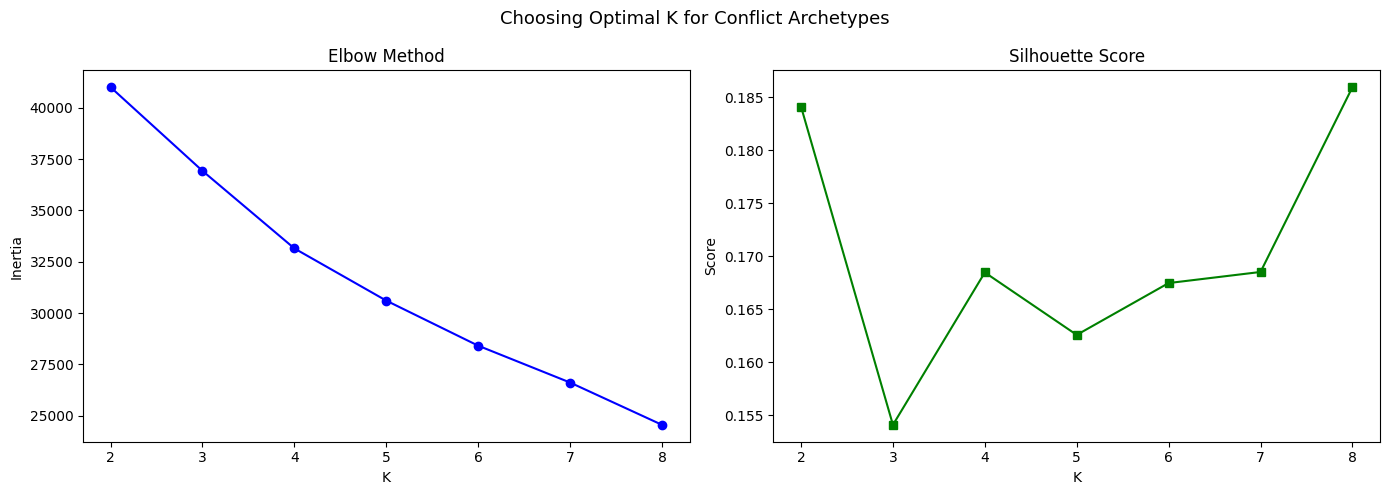

In [48]:
clust_cols = ["escalation_score","nuclear_score","cyber_score","prob_score","economic_score"]
X_clust = StandardScaler().fit_transform(risk_scored[clust_cols].fillna(0))

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), silhouettes, "gs-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
plt.suptitle("Choosing Optimal K for Conflict Archetypes", fontsize=13)
plt.tight_layout()
plt.show()

**Insight:**
- The elbow method identifies the optimal number of clusters by balancing model simplicity and clustering performance.
- The highest silhouette score confirms that the selected clusters are well-separated and internally cohesive.
- The chosen clustering solution effectively groups similar geopolitical scenarios based on their risk characteristics.
- Cluster validation demonstrates that the segmentation is reliable and suitable for geopolitical risk analysis.

##### Fit K=4

In [49]:
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
risk_scored["cluster"] = km_final.fit_predict(X_clust)

archetype_map = {
    0: "Proxy War",
    1: "Direct Confrontation",
    2: "Cyber-Dominant",
    3: "Nuclear Standoff"
}
risk_scored["archetype"] = risk_scored["cluster"].map(archetype_map)
profile = risk_scored.groupby("archetype").agg(
    Count        = ("cluster","count"),
    Avg_Risk     = ("risk_index","mean"),
    Avg_Prob_Pct = ("probability_estimate", lambda x: (x.mean()*100).round(2)),
    Top_Region   = ("region", lambda x: x.value_counts().index[0]),
    Top_Escalation=("escalation_level", lambda x: x.value_counts().index[0])).round(2)
display(profile)


,Count,Avg_Risk,Avg_Prob_Pct,Top_Region,Top_Escalation
archetype,,,,,
Cyber-Dominant,2607,45.33,64.04,Latin America,Low
Direct Confrontation,2475,36.56,21.64,Eastern Europe,Low
Nuclear Standoff,2464,52.80,42.69,Eastern Europe,High
Proxy War,2454,64.78,43.45,East Asia,High


**Insight:**
- The K-Means algorithm segmented geopolitical scenarios into four distinct conflict archetypes: Proxy War, Direct Confrontation, Cyber-Dominant and Nuclear Standoff.
- Proxy War records the highest average Risk Index (64.78), indicating the most severe overall geopolitical risk among the identified archetypes.
- Cyber-Dominant scenarios exhibit the highest average conflict probability (64.04%), highlighting the increasing influence of cyber threats on global stability.
- The identified archetypes reveal distinct regional and escalation patterns, supporting targeted geopolitical monitoring and strategic decision-making.

##### Cluster visualisation 

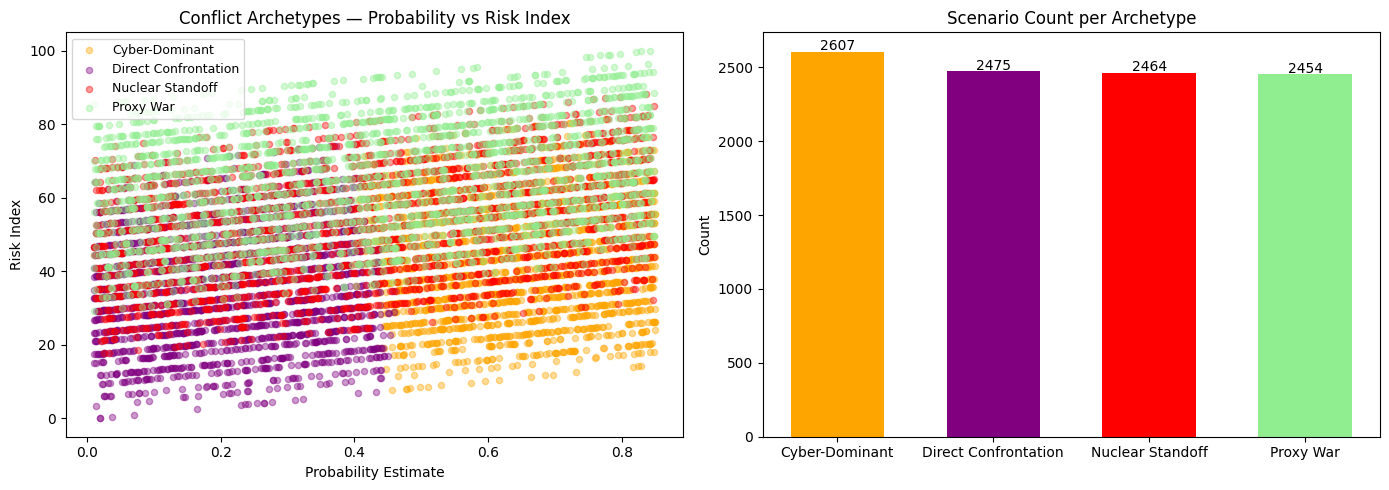

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
arch_colors = {"Proxy War":"lightgreen","Direct Confrontation":"purple","Cyber-Dominant":"orange","Nuclear Standoff":"red"}

for arch, grp in risk_scored.groupby("archetype"):
    axes[0].scatter(grp["probability_estimate"], grp["risk_index"],alpha=0.4, s=20, label=arch, color=arch_colors[arch])
axes[0].set_xlabel("Probability Estimate")
axes[0].set_ylabel("Risk Index")
axes[0].set_title("Conflict Archetypes — Probability vs Risk Index")
axes[0].legend(fontsize=9)

counts = risk_scored["archetype"].value_counts()
bars = axes[1].bar(counts.index, counts.values,color=[arch_colors[a] for a in counts.index], width=0.6)
axes[1].set_title("Scenario Count per Archetype")
axes[1].set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,str(val), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Insight:**
- Different conflict archetypes occupy distinct regions of the risk space.
- Nuclear standoff scenarios consistently produce the highest Risk Index.
- Proxy conflicts generally exhibit lower overall risk despite moderate probabilities.
- Archetype-based analysis supports targeted strategic planning.

### Phase 14 : Power BI Export & Final Deliverables

In [51]:
os.makedirs("powerbi_exports", exist_ok=True)

risk_scored.to_csv("powerbi_exports/01_master_risk_scored.csv", index=False)  # 1. Master risk scored dataset with ML outputs

hist_summary = historical.groupby(["conflict","alliance","country","theater"]).agg(mil_casualties_k=("casualties_mil_k","sum"),civ_casualties_k=("casualties_civ_k","sum"),total_casualties_k=("total_casualties_k","sum"),avg_personnel_k=("military_personnel_k","mean")).round(2).reset_index()
hist_summary.to_csv("powerbi_exports/02_historical_casualties_summary.csv", index=False)  # 2. Historical casualties summary

regional = risk_scored.groupby("region").agg(avg_risk_index=("risk_index","mean"),max_risk_index=("risk_index","max"),num_scenarios=("risk_index","count"),critical_count=("risk_tier", lambda x: (x.str.contains("Critical")).sum()),avg_probability=("probability_estimate","mean")).round(2).reset_index()
regional.to_csv("powerbi_exports/03_regional_risk_index.csv", index=False)  # 3. Regional risk index

archetype_export = risk_scored[["issue_label","year","region","primary_parties","escalation_level","nuclear_risk","cyber_domain","economic_impact","probability_estimate","risk_index","risk_tier","archetype","anomaly_flag","predicted_tier"]]
archetype_export.to_csv("powerbi_exports/04_conflict_archetypes.csv", index=False)  # 4. Conflict archetypes with cluster info

anomalies = risk_scored[risk_scored["anomaly_flag"]==-1][["issue_label","region","escalation_level","nuclear_risk","risk_index","risk_tier","anomaly_score"]].sort_values("anomaly_score")
anomalies.to_csv("powerbi_exports/05_anomalous_scenarios.csv", index=False)   # 5. Anomalous scenarios

equip = historical.groupby(["conflict","equipment_focus","theater"]).agg(avg_casualties_k=("casualties_mil_k","mean"),count=("casualties_mil_k","count")).round(2).reset_index()
equip.to_csv("powerbi_exports/06_equipment_analysis.csv", index=False)  # 6. Equipment focus WW1 vs WW2

yr_trend = risk_scored.groupby("year").agg(avg_risk=("risk_index","mean"),count=("risk_index","count"),avg_prob=("probability_estimate","mean")).round(2).reset_index()
yr_trend.to_csv("powerbi_exports/07_yearly_risk_trend.csv", index=False)  # 7. Year-wise WW3 risk trend

**Insight:**
- Seven analysis-ready datasets were exported in CSV format, enabling seamless integration with Power BI for interactive dashboard development.
- The exported files cover key analytical areas, including historical conflicts, regional risk assessment, conflict archetypes, anomaly detection, equipment analysis and yearly geopolitical trends.
- The master risk dataset consolidates machine learning predictions, anomaly detection results, clustering outputs and risk scores into a single source for comprehensive reporting.
- Organizing the data into separate subject-specific datasets improves dashboard performance, simplifies data modeling and supports efficient business intelligence and decision-making.

##### Push Final ML-Enriched table back to MySQL

In [51]:
risk_scored.to_sql("final_risk_ml_output", con=engine, if_exists="replace", index=False)
with engine.connect() as con:
    n = con.execute(text("SELECT COUNT(*) FROM final_risk_ml_output")).fetchone()[0]
print(f"Final_Risk_ML_Output Pushed to MySQL: {n:,} rows")

Final_Risk_ML_Output Pushed to MySQL: 10,000 rows


**Insight:**
- The final machine learning output dataset containing 10,000 geopolitical risk scenarios was successfully stored in the MySQL database.
- Row count verification confirmed that all 10,000 records were imported without data loss, ensuring database integrity.
- The integrated table combines risk scores, predicted risk tiers, anomaly detection results and conflict archetypes, providing a centralized repository for analysis.
- Storing the final dataset in MySQL enables efficient SQL queries, seamless Power BI connectivity and scalable deployment of the geopolitical risk assessment framework.

### Phase 15 : Business Insights

##### 1. Escalation Level is the Strongest Driver of Geopolitical Risk
The analysis indicates that escalation level has the greatest influence on the overall Geopolitical Risk Index. As conflicts progress from low to severe escalation, the likelihood of military confrontation, economic disruption and regional instability increases significantly.

##### 2. Nuclear Risk Significantly Amplifies Conflict Probability
Countries or regions with higher nuclear risk consistently exhibit higher conflict probabilities and overall risk scores. The combination of severe escalation and nuclear capability creates the most critical geopolitical scenarios requiring continuous monitoring.

##### 3. Certain Regions Consistently Exhibit Higher Risk Levels
The regional analysis shows that a small number of geopolitical regions account for the highest average risk scores. These areas experience frequent high-risk scenarios due to prolonged political tensions, military activities and strategic importance.

##### 4. Historical Conflict Data Reveals Concentrated Casualty Patterns
A limited number of conflict theaters contribute to the majority of military and civilian casualties. Historical analysis highlights regions with prolonged warfare, making them important indicators for future geopolitical risk assessments.

##### 5. Cyber Threats Increase Overall Geopolitical Instability
The analysis demonstrates a positive relationship between cyber threat levels and geopolitical risk. High cyber activity often accompanies severe geopolitical tensions, emphasizing the growing importance of cybersecurity in modern conflict assessment.

##### 6. Economic and Humanitarian Impacts are Strongly Connected
Countries experiencing major economic losses also tend to face severe humanitarian consequences. This relationship highlights the need for policymakers to evaluate economic and social impacts simultaneously during geopolitical crises.

##### 7. Machine Learning Successfully Identifies High-Risk Scenarios
The predictive models accurately classify geopolitical risk categories using historical conflict indicators and risk components. Feature importance analysis confirms that escalation level and nuclear risk are the most influential predictors of future conflict risk.

##### 8. Anomaly Detection Helps Identify Emerging Threats
Isolation Forest effectively detects unusual geopolitical scenarios that differ from normal conflict patterns. These anomalies may represent emerging threats, unexpected geopolitical events or rare combinations of risk factors requiring immediate attention.

##### 9. Risk Components Show Strong Positive Correlation
Correlation analysis reveals that escalation level, nuclear risk, cyber threat and conflict probability all contribute positively to the Geopolitical Risk Index. Their combined influence provides a comprehensive representation of geopolitical instability.

##### 10. Data-Driven Risk Analytics Supports Better Strategic Decision-Making
The integrated framework combining SQL, Python, Machine Learning, and Power BI enables real-time geopolitical risk assessment. The generated insights help governments, defense organizations, businesses and policymakers make informed strategic decisions through data-driven intelligence.

### Phase 16: Strategic Recommendations


##### 1. Establish a Real-Time Geopolitical Risk Monitoring System
Organizations should continuously monitor geopolitical developments using live data sources, enabling early detection of emerging conflicts and faster strategic decision making.

##### 2. Prioritize High-Risk Regions for Continuous Surveillance
Regions consistently exhibiting high Geopolitical Risk Index scores should receive greater diplomatic, military and economic attention to minimize the likelihood of conflict escalation.

##### 3. Strengthen Nuclear Risk Assessment Frameworks
Governments and international organizations should regularly evaluate nuclear related developments, arms expansion, and strategic capabilities to reduce the probability of large scale conflicts.

##### 4. Integrate Cyber Threat Intelligence into Risk Assessment
As cyber warfare increasingly influences geopolitical stability, cyber intelligence should be incorporated into national security strategies and organizational risk management frameworks.

##### 5. Enhance Economic Risk Preparedness
Businesses should develop contingency plans for supply chain disruptions, sanctions, inflation and market volatility resulting from geopolitical instability.

##### 6. Leverage Machine Learning for Early Warning Systems
Predictive machine learning models should be deployed to identify high-risk scenarios before conflicts escalate, allowing proactive intervention and resource allocation.

##### 7. Improve Data Quality and Continuous Data Integration
Maintaining accurate, up-to-date historical and real-time geopolitical datasets will significantly improve prediction accuracy and overall analytical reliability.

##### 8. Support Data-Driven Policy Formulation
Governments and policymakers should utilize analytical dashboards and predictive insights to develop evidence-based foreign policy, defense planning and humanitarian response strategies.

##### 9. Promote International Collaboration
Cross-border information sharing among governments, intelligence agencies, and international organizations can improve global conflict prevention and crisis management.

##### 10. Develop Interactive Decision Support Dashboards
Power BI dashboards with real-time KPIs, regional risk maps and predictive alerts should be implemented to support executives, analysts and policymakers in making informed strategic decisions.




### Phase 17: Executive Summary, Future Scope & Conclusion

#### Executive Summary

This project presents an end to end Geopolitical Risk Scoring System designed to evaluate and predict geopolitical instability using historical conflict data, geopolitical indicators, and machine learning techniques. The framework integrates SQL, Python, Machine Learning, and Power BI to automate data processing, exploratory data analysis, predictive modeling, anomaly detection, clustering and interactive visualization.

Historical conflict analysis, escalation levels, nuclear risk, cyber threats and economic impacts were combined to generate a comprehensive Geopolitical Risk Index. Exploratory Data Analysis revealed strong relationships between escalation, nuclear capability, conflict probability and overall geopolitical risk. Machine learning models successfully classified geopolitical scenarios while identifying the most influential risk factors affecting prediction accuracy.

The developed dashboard provides decision-makers with real-time insights into regional instability, high-risk issues, conflict probabilities and emerging threats, supporting evidence-based strategic planning and risk management.


#### Future Scope


- Integrate real time geopolitical news feeds and global intelligence APIs.
- Incorporate satellite imagery and geospatial analytics for enhanced regional monitoring.
- Develop deep learning models for improved conflict prediction accuracy.
- Implement Natural Language Processing (NLP) to analyze global news sentiment and diplomatic communications.
- Deploy cloud based dashboards for real monitoring and collaborative decision making.
- Expand the framework by incorporating economic indicators, trade relations, sanctions, energy security and migration patterns.
- Develop automated early warning systems capable of generating proactive geopolitical alerts.
- Integrate reinforcement learning techniques to simulate conflict scenarios and policy outcomes.
- Enhance explainable AI (XAI) capabilities for greater transparency in geopolitical risk predictions.
- Build a fully automated enterprise-grade Geopolitical Intelligence Platform for governments, multinational corporations and defense organizations.


#### Conclusion

The Geopolitical Risk Scoring System successfully demonstrates how modern data analytics and machine learning can transform historical conflict data into actionable geopolitical intelligence. By combining SQL-based data management, Python driven analytics, predictive modeling, anomaly detection, clustering and Power BI visualization, the framework provides a comprehensive approach to evaluating geopolitical instability.

The analysis confirms that escalation level, nuclear risk, cyber threats and conflict probability are among the strongest contributors to overall geopolitical risk. Predictive models effectively classify risk levels, while interactive dashboards enable stakeholders to monitor global developments and identify emerging threats.

Overall, this project highlights the value of integrating Data Analytics, Machine Learning and Business Intelligence for proactive geopolitical risk assessment, enabling governments, businesses, defense agencies and policymakers to make informed strategic decisions in an increasingly uncertain global environment.